<a href="https://colab.research.google.com/github/kentodemonII/movie-ticket-analysis/blob/main/projectTicket.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
pd.set_option('display.max_columns',None)



In [ ]:
df_campaign=pd.read_csv('/content/drive/MyDrive/dataset/campaign1.csv')

In [ ]:
df_device=pd.read_csv('/content/drive/MyDrive/dataset/device_detail1.csv')

In [ ]:
df_customer=pd.read_csv('/content/drive/MyDrive/dataset/customer1.csv')

In [ ]:
df_status=pd.read_csv('/content/drive/MyDrive/dataset/status_detail1.csv')

In [ ]:
df_ticket=pd.read_csv('/content/drive/MyDrive/dataset/ticket_history1.csv')

#2 Data Cleaning

## 2.1. data type , null values , duplicates

In [ ]:
#customer
df_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 131400 entries, 0 to 131399
Data columns (total 3 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   customer_id  131400 non-null  int64 
 1   usergender   131400 non-null  object
 2   dob          131400 non-null  object
dtypes: int64(1), object(2)
memory usage: 3.0+ MB


In [ ]:
df_customer.head(2)

,customer_id,usergender,dob
0,100032,Female,8/8/1985
1,100046,Male,7/11/1987


In [ ]:
#chuyen doi datatype thanh datetime
from datetime import datetime
df_customer['dob']=pd.to_datetime(df_customer['dob'])

In [ ]:
df_customer['customer_id'].nunique()

131400

In [ ]:
#campaign
df_campaign.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 216 entries, 0 to 215
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   campaign_id    216 non-null    int64 
 1   campaign_type  216 non-null    object
dtypes: int64(1), object(1)
memory usage: 3.5+ KB


In [ ]:
df_campaign.head(2)

,campaign_id,campaign_type
0,106460,direct discount
1,30040,direct discount


In [ ]:
df_campaign['campaign_id'].nunique()

216

In [ ]:
#device
df_device.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 139902 entries, 0 to 139901
Data columns (total 3 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   device_number  139901 non-null  object
 1   model          132763 non-null  object
 2   platform       139902 non-null  object
dtypes: object(3)
memory usage: 3.2+ MB


In [ ]:
df_device.head(2)

,device_number,model,platform
0,00006afbe30ae7018c92bb324cd58afc,browser,website
1,0000b0ce524ef4d66c7bfdad67a91970,devicemodel,mobile


In [ ]:
df_device['device_number'].nunique()

139901

In [ ]:
def calc_null_rate(df):
    newdf = df.isnull().sum().to_frame('null_count')
    newdf['null_rate'] = newdf['null_count'] / len(df)
    return newdf.sort_values(by='null_rate', ascending=False)

In [ ]:
calc_null_rate(df_device)

,null_count,null_rate
model,7139,0.051029
device_number,1,0.000007
platform,0,0.000000


In [ ]:
#Thay the null cot model thanh unknown
#xoa NULL trong device_id
df_device=df_device.dropna(subset=['device_number'])
df_device=df_device.fillna({'model':'unknown'})

In [ ]:
df_device.info()

<class 'pandas.core.frame.DataFrame'>
Index: 139901 entries, 0 to 139900
Data columns (total 3 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   device_number  139901 non-null  object
 1   model          139901 non-null  object
 2   platform       139901 non-null  object
dtypes: object(3)
memory usage: 4.3+ MB


In [ ]:
calc_null_rate(df_device)

,null_count,null_rate
device_number,0,0.0
model,0,0.0
platform,0,0.0


In [ ]:
#status
df_status.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   status_id    8 non-null      int64 
 1   description  8 non-null      object
 2   error_group  7 non-null      object
dtypes: int64(1), object(2)
memory usage: 324.0+ bytes


In [ ]:
calc_null_rate(df_status)

,null_count,null_rate
error_group,1,0.125
status_id,0,0.000
description,0,0.000


In [ ]:
df_status.head(10)

,status_id,description,error_group
0,1,Order successful,NaN
1,-1,Payment overdue,customer
2,-2,Insufficient funds in customer account. Please...,customer
3,-3,No response from your bank,external
4,-4,Password locked due to multiple incorrect atte...,customer
5,-5,Payment failed from bank,external
6,-6,Need verify your account to continue,customer
7,-7,Transaction temporarily limited,internal


In [ ]:
#ticket
df_ticket.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 154827 entries, 0 to 154826
Data columns (total 12 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   ticket_id       154827 non-null  object 
 1   customer_id     154827 non-null  int64  
 2   paying_method   154827 non-null  object 
 3   theater_name    154827 non-null  float64
 4   device_number   154827 non-null  object 
 5   original_price  154827 non-null  float64
 6   discount_value  154827 non-null  float64
 7   final_price     154827 non-null  float64
 8   time            154827 non-null  object 
 9   status_id       154827 non-null  int64  
 10  campaign_id     154827 non-null  int64  
 11  movie_name      154827 non-null  object 
dtypes: float64(4), int64(3), object(5)
memory usage: 14.2+ MB


In [ ]:
df_ticket.head(2)

,ticket_id,customer_id,paying_method,theater_name,device_number,original_price,discount_value,final_price,time,status_id,campaign_id,movie_name
0,4f5200dcdcf2396b8d50ff84bf423f32,100009,money in app,13.0,244764a57dbdeb8fe9b164847ad55183,9.90,2.10,7.80,2022-07-08 17:46:36.145,1,83330,Thor: Love And Thunder
1,07abbaf28c772692f0367ad992bb3184,100493,bank account,180.0,8fa83cf46284aafd6e5da6c96f7862b5,8.66,1.48,7.18,2022-07-15 20:44:09.952,1,83330,Thor: Love And Thunder


In [ ]:
df_ticket['time']=pd.to_datetime(df_ticket['time'])

In [ ]:
calc_null_rate(df_ticket)

,null_count,null_rate
ticket_id,0,0.0
customer_id,0,0.0
paying_method,0,0.0
theater_name,0,0.0
device_number,0,0.0
original_price,0,0.0
discount_value,0,0.0
final_price,0,0.0
time,0,0.0
status_id,0,0.0


In [ ]:
df_ticket['ticket_id'].nunique()

154725

In [ ]:
df_dup=df_ticket[df_ticket.duplicated(keep=False)]

In [ ]:
df_dup.head(10)

,ticket_id,customer_id,paying_method,theater_name,device_number,original_price,discount_value,final_price,time,status_id,campaign_id,movie_name
3555,c56e3eb9fb1fd241c9de7a700d7a52d2,206709,money in app,5.0,291f6a5c77b7d98a86fe76bdbabe94eb,5.77,1.03,4.74,2022-07-02 22:11:30.005,1,85940,Thor: Love And Thunder
3556,c56e3eb9fb1fd241c9de7a700d7a52d2,206709,money in app,5.0,291f6a5c77b7d98a86fe76bdbabe94eb,5.77,1.03,4.74,2022-07-02 22:11:30.005,1,85940,Thor: Love And Thunder
49730,763e20c9c1136c5c06d9a960fac9dae6,174180,credit card,29.0,ba5794fca2cba47fd0141dd3fb195934,7.42,0.00,7.42,2019-12-23 15:28:45.738,1,0,Dreamy Eyes
49731,763e20c9c1136c5c06d9a960fac9dae6,174180,credit card,29.0,ba5794fca2cba47fd0141dd3fb195934,7.42,0.00,7.42,2019-12-23 15:28:45.738,1,0,Dreamy Eyes
49876,257d0a0e6a7f38b90b5ecdfa9e8416b9,133912,money in app,119.0,18abc497c03f7e6bd0b0cf72a89fb911,7.42,0.00,7.42,2019-12-23 18:04:51.790,1,0,Dreamy Eyes
49877,257d0a0e6a7f38b90b5ecdfa9e8416b9,133912,money in app,119.0,18abc497c03f7e6bd0b0cf72a89fb911,7.42,0.00,7.42,2019-12-23 18:04:51.790,1,0,Dreamy Eyes
50202,6dec59a668243f07301d5bf3c2368fa0,111474,debit card,109.0,a07a8e335cc40b1e39e2d7fc9a9af557,8.66,0.00,8.66,2019-12-23 10:35:45.542,1,0,Dreamy Eyes
50203,6dec59a668243f07301d5bf3c2368fa0,111474,debit card,109.0,a07a8e335cc40b1e39e2d7fc9a9af557,8.66,0.00,8.66,2019-12-23 10:35:45.542,1,0,Dreamy Eyes
50212,5f377be63fca730d5b5d12e06ac3f05d,117355,credit card,53.0,9092a5b635cbcf89633ff48766bc04e6,7.84,0.00,7.84,2019-12-23 19:30:23.767,1,0,Dreamy Eyes
50213,5f377be63fca730d5b5d12e06ac3f05d,117355,credit card,53.0,9092a5b635cbcf89633ff48766bc04e6,7.84,0.00,7.84,2019-12-23 19:30:23.767,1,0,Dreamy Eyes


In [ ]:
df_ticket.drop_duplicates(inplace=True)

In [ ]:
df_ticket.info()

<class 'pandas.core.frame.DataFrame'>
Index: 154725 entries, 0 to 154826
Data columns (total 12 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   ticket_id       154725 non-null  object        
 1   customer_id     154725 non-null  int64         
 2   paying_method   154725 non-null  object        
 3   theater_name    154725 non-null  float64       
 4   device_number   154725 non-null  object        
 5   original_price  154725 non-null  float64       
 6   discount_value  154725 non-null  float64       
 7   final_price     154725 non-null  float64       
 8   time            154725 non-null  datetime64[ns]
 9   status_id       154725 non-null  int64         
 10  campaign_id     154725 non-null  int64         
 11  movie_name      154725 non-null  object        
dtypes: datetime64[ns](1), float64(4), int64(3), object(4)
memory usage: 15.3+ MB


##2.2. join

In [ ]:
df_j_cus=pd.merge(df_customer,df_ticket,on='customer_id',how='right')
df_j_cus.info()
df_j_cam=pd.merge(df_j_cus,df_campaign,on='campaign_id',how='left')
df_j_cam.info()
df_j_dev=pd.merge(df_j_cam,df_device,on='device_number',how='left')
df_j_dev.info()
df_j_all=pd.merge(df_j_dev,df_status,on='status_id',how='left')
df_j_all.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 154725 entries, 0 to 154724
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   customer_id     154725 non-null  int64         
 1   usergender      154725 non-null  object        
 2   dob             154725 non-null  datetime64[ns]
 3   ticket_id       154725 non-null  object        
 4   paying_method   154725 non-null  object        
 5   theater_name    154725 non-null  float64       
 6   device_number   154725 non-null  object        
 7   original_price  154725 non-null  float64       
 8   discount_value  154725 non-null  float64       
 9   final_price     154725 non-null  float64       
 10  time            154725 non-null  datetime64[ns]
 11  status_id       154725 non-null  int64         
 12  campaign_id     154725 non-null  int64         
 13  movie_name      154725 non-null  object        
dtypes: datetime64[ns](2), float64(4), in

In [ ]:
df_j_all.fillna('unkown',inplace=True)

In [ ]:
calc_null_rate(df_j_all)

,null_count,null_rate
customer_id,0,0.0
usergender,0,0.0
dob,0,0.0
ticket_id,0,0.0
paying_method,0,0.0
theater_name,0,0.0
device_number,0,0.0
original_price,0,0.0
discount_value,0,0.0
final_price,0,0.0


In [ ]:
df_j_all['customer_id']=df_j_all['customer_id'].astype(str)

##2.3. View all values of each columns

In [ ]:
df_j_all.nunique().sort_values(ascending=False)

,0
ticket_id,154725
time,154725
device_number,126459
customer_id,119477
dob,11322
final_price,2715
original_price,1895
model,1216
movie_name,253
discount_value,242


In [ ]:
specific_cols = ['movie_name', 'description', 'paying_method', 'campaign_type', 'usergender', 'platform', 'error_group']
for col in specific_cols:
    print(col + ': ' + np.sort(df_j_all[col].unique().astype(str)))
    print('\r')
    print('---------------------')
    print('\r')

['movie_name: 13rd Sister' 'movie_name: 13rd Sister: Three Deadly Days'
 'movie_name: 1990' 'movie_name: 2037' 'movie_name: 30 Chua Phai Tet'
 'movie_name: 47 Meters Down: Uncaged' 'movie_name: A Chamada Da Selva'
 'movie_name: A Diamond In The Rough' 'movie_name: Accidentally Dad'
 'movie_name: Aladdin' 'movie_name: Alienoid'
 'movie_name: Alita: Battle Angel' 'movie_name: Ambulance'
 'movie_name: Anchor' 'movie_name: Angel Has Fallen' 'movie_name: Anna'
 'movie_name: Annabelle Comes Home' 'movie_name: Aquaman'
 'movie_name: Around The World In 80 Days' 'movie_name: Autumn Promise'
 'movie_name: Avatar' 'movie_name: Avatar: The Way Of Water'
 'movie_name: Avengers: Endgame' 'movie_name: Bad Boys For Life'
 'movie_name: Batman' 'movie_name: Beast' 'movie_name: Birds Of Prey'
 'movie_name: Black Adam' 'movie_name: Black Panther 2: Wakanda Forever'
 'movie_name: Black Panther: Wakanda Forever' 'movie_name: Blood Karma'
 'movie_name: Blood Moon Party' 'movie_name: Bloodshot'
 'movie_name:

In [ ]:
df_j_all['error_group'].unique()

array(['unkown', 'external', 'customer', 'internal'], dtype=object)

#3 Analyze

##3.1 Customer portrait

###Age and gender

In [ ]:
#Tinh so tuoi
current_date=datetime.now()

In [ ]:
df_j_all['age']=(((current_date-df_j_all['dob']).dt.days)/365.25).apply(np.floor).astype(int)

In [ ]:
df_j_all

,customer_id,usergender,dob,ticket_id,paying_method,theater_name,device_number,original_price,discount_value,final_price,time,status_id,campaign_id,movie_name,campaign_type,model,platform,description,error_group,age
0,100009,Male,1989-02-25,4f5200dcdcf2396b8d50ff84bf423f32,money in app,13.0,244764a57dbdeb8fe9b164847ad55183,9.90,2.10,7.80,2022-07-08 17:46:36.145,1,83330,Thor: Love And Thunder,direct discount,"iPhone13,1",mobile,Order successful,unkown,36
1,100493,Male,1991-06-09,07abbaf28c772692f0367ad992bb3184,bank account,180.0,8fa83cf46284aafd6e5da6c96f7862b5,8.66,1.48,7.18,2022-07-15 20:44:09.952,1,83330,Thor: Love And Thunder,direct discount,browser,website,Order successful,unkown,34
2,100596,Male,1989-05-18,1fdbeb7eceba8a27d9d985b5b70c219a,money in app,56.0,69cf9244654949047f006e441fa7a8a7,10.31,2.31,8.00,2022-07-30 11:16:55.483,1,0,Thor: Love And Thunder,unkown,unknown,mobile,Order successful,unkown,36
3,100852,Male,1997-08-31,7715c9955866bd296b98543412839abd,bank account,119.0,879ed11af9d6d2b5cda4d299590735a7,27.75,1.03,26.72,2022-07-04 22:33:07.458,1,85940,Thor: Love And Thunder,direct discount,devicemodel,mobile,Order successful,unkown,28
4,100965,Male,1988-09-20,776efd7bda0b715084430e6385f67746,money in app,107.0,0a233600d993a02cc1d39fb0d87fc7de,4.33,1.03,3.30,2022-07-03 18:41:45.098,1,85940,Thor: Love And Thunder,direct discount,devicemodel,mobile,Order successful,unkown,37
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
154720,194726,Male,2001-01-21,6d81d62a2d26adb4c9b47d254a2bfe27,debit card,70.0,f5ad6683cca252327b19bef18f0e8a65,5.16,2.31,2.85,2022-10-22 13:01:58.840,-5,97120,Black Adam,direct discount,devicemodel,mobile,Payment failed from bank,external,24
154721,211166,Male,1995-05-05,740855b0fdc18125b773f904279d2dfb,money in app,101.0,217e197a017719ed96da9c140968a15f,5.07,0.00,5.07,2022-10-23 10:51:32.185,1,0,Black Adam,unkown,devicemodel,mobile,Order successful,unkown,30
154722,211671,Male,1980-05-19,9a65bf4e0ab9da0186007404f6ec0960,money in app,176.0,627e3c4a56079dff9fd3a6f0f77ae13c,14.72,2.31,12.41,2022-10-23 11:11:23.037,1,97120,Black Adam,direct discount,devicemodel,mobile,Order successful,unkown,45
154723,223500,Not verify,1970-01-01,e47b196dbb5b487b3f6cf1cabe242552,bank account,176.0,f6836889dc1bbc02547e23a1c59a8bb2,13.36,4.78,8.58,2022-10-22 20:35:02.732,1,97150,Black Adam,direct discount,browser,website,Order successful,unkown,55


In [ ]:
#lay danh sach khach hang kem thong tin va do tuoi
df_cus=df_j_all.drop_duplicates(subset=['customer_id'])[['customer_id','dob','age','usergender']]

In [ ]:
df_cus.head()

,customer_id,dob,age,usergender
0,100009,1989-02-25,36,Male
1,100493,1991-06-09,34,Male
2,100596,1989-05-18,36,Male
3,100852,1997-08-31,28,Male
4,100965,1988-09-20,37,Male


In [ ]:
df_cus[(df_cus['age']>=26)&(df_cus['age']<=35)]['customer_id'].count()/df_cus['customer_id'].count()

np.float64(0.5798772985595554)

Text(0, 0.5, 'Number of customers')

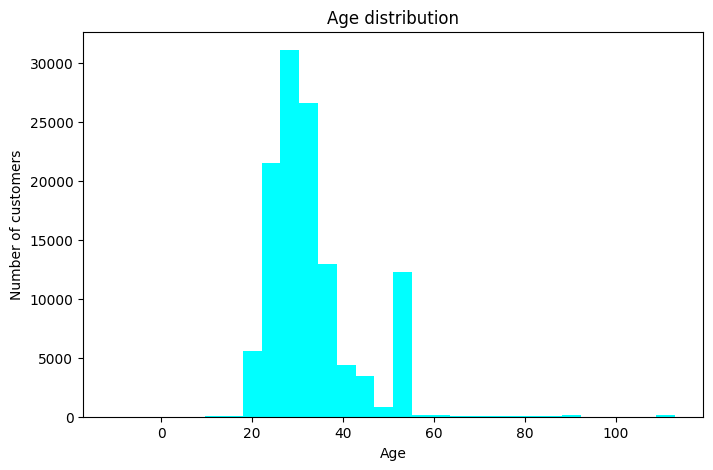

In [ ]:
#Phân bổ khách hàng theo biểu đồ
plt.figure(figsize=(8,5))
plt.hist(df_cus['age'],bins=30,color='cyan')
plt.title('Age distribution')
plt.xlabel('Age')
plt.ylabel('Number of customers')

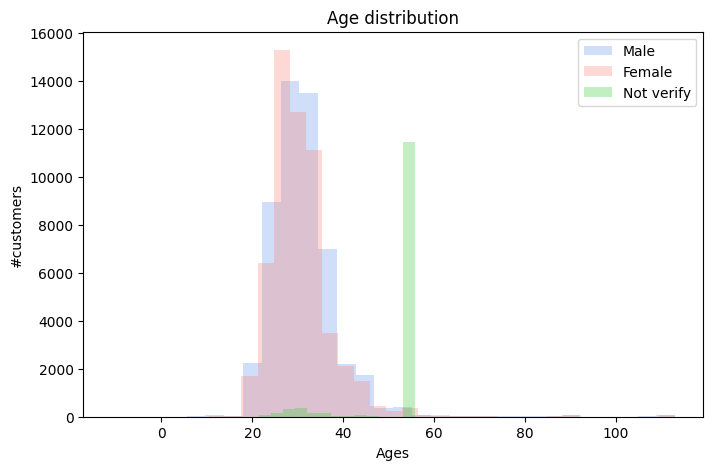

In [ ]:
#Phân bổ độ tuổi theo giới tính
plt.figure(figsize=(8,5))
#data
male_age = df_cus[df_cus['usergender'] == 'Male']['age']
female_age = df_cus[df_cus['usergender'] == 'Female']['age']
unknown_age = df_cus[df_cus['usergender'] == 'Not verify']['age']
#plot
plt.hist(male_age, bins=30, alpha=0.3, color='cornflowerblue', label='Male')
plt.hist(female_age, bins=30, alpha=0.3, color='salmon', label='Female')
plt.hist(unknown_age, bins=30, alpha=0.3, color='limegreen', label='Not verify')

plt.title('Age distribution')
plt.xlabel('Ages')
plt.ylabel('#customers')
plt.legend()
plt.show()


In [ ]:
#ĐÁnh giá nhóm Not Verify
df_gen=df_cus.groupby('usergender').agg(totalcus=('customer_id','count')).sort_values(by='totalcus',ascending=False).reset_index()


Text(0.5, 1.0, 'Gender distribution')

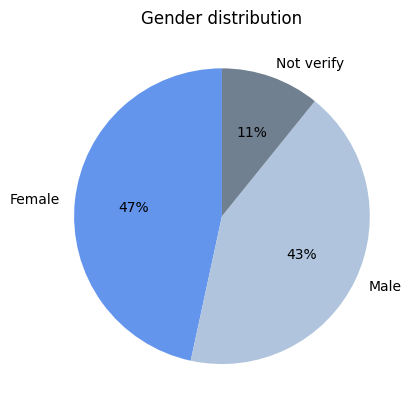

In [ ]:
plt.pie(df_gen['totalcus'],labels=df_gen['usergender'],colors=['cornflowerblue', 'lightsteelblue', 'slategrey'],autopct='%1.0f%%',startangle=90)
plt.title('Gender distribution')

**Notes**

- Nhóm KH chưa verify tài khoản chiếm hơn 10%. Dẫn tới 2 trường hợp:
  - Nếu họ nhập dob thì sẽ có data
  - Nếu họ không nhập thì hệ thống sẽ auto fill là 1970 ---> 55 tuổi 🐸


In [ ]:
df_cus[df_cus['usergender']=='Not verify'].groupby('age').agg(totalcus=('customer_id','count')).sort_values(by='totalcus',ascending=False).reset_index()


,age,totalcus
0,55,11435
1,30,124
2,29,119
3,31,117
4,27,115
5,32,109
6,28,108
7,33,99
8,26,94
9,35,85


###Age generation distribution

In [ ]:
df_cus

,customer_id,dob,age,usergender
0,100009,1989-02-25,36,Male
1,100493,1991-06-09,34,Male
2,100596,1989-05-18,36,Male
3,100852,1997-08-31,28,Male
4,100965,1988-09-20,37,Male
...,...,...,...,...
154720,194726,2001-01-21,24,Male
154721,211166,1995-05-05,30,Male
154722,211671,1980-05-19,45,Male
154723,223500,1970-01-01,55,Not verify


In [ ]:
df_cus['generation'] = (
    df_cus['dob']
    .apply(lambda x: 'baby bomer' if x.year<1965
           else 'gen X' if x.year<1981
           else 'gen Y' if x.year<1997
           else 'gen Z')
)

In [ ]:
df_cus

,customer_id,dob,age,usergender,generation
0,100009,1989-02-25,36,Male,gen Y
1,100493,1991-06-09,34,Male,gen Y
2,100596,1989-05-18,36,Male,gen Y
3,100852,1997-08-31,28,Male,gen Z
4,100965,1988-09-20,37,Male,gen Y
...,...,...,...,...,...
154720,194726,2001-01-21,24,Male,gen Z
154721,211166,1995-05-05,30,Male,gen Y
154722,211671,1980-05-19,45,Male,gen X
154723,223500,1970-01-01,55,Not verify,gen X


In [ ]:
df_gen_group=df_cus[df_cus['usergender']!='Not verify'].groupby('generation').agg(total =('customer_id','count')).sort_values(by='total',ascending=False).reset_index()

Text(0.5, 1.0, 'Age generation distribution')

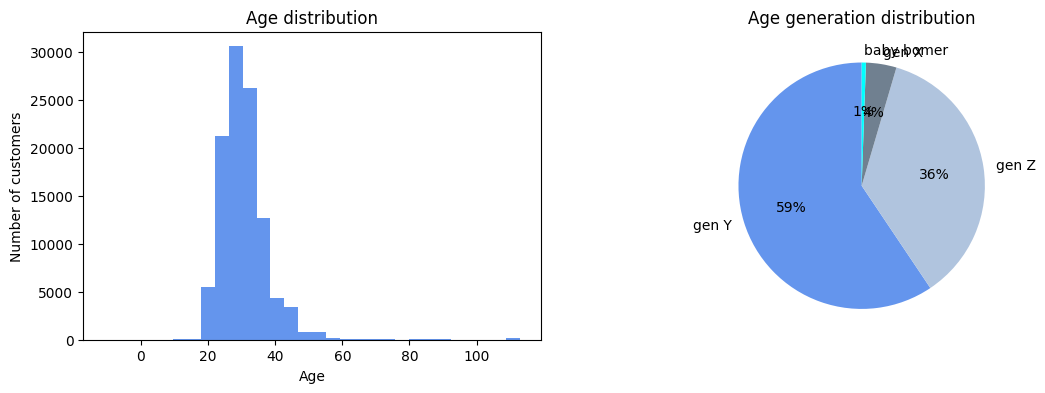

In [ ]:
#Kết hợp 2 biểu đồ
plt.figure(figsize=(13,4))
#plot 1
ax1=plt.subplot(1,2,1)
df_cus[df_cus['usergender']!='Not verify']['age'].hist(bins=30,color='cornflowerblue',grid=False)
plt.title('Age distribution')
plt.xlabel('Age')
plt.ylabel('Number of customers')
#plot 2
ax2=plt.subplot(1,2,2)
plt.pie(df_gen_group['total'],labels=df_gen_group['generation'],colors=['cornflowerblue', 'lightsteelblue', 'slategrey','cyan'],autopct='%1.0f%%',startangle=90)
plt.title('Age generation distribution')



In [ ]:
df_cus[(df_cus['age']>=26)&(df_cus['age']<=35)&(df_cus['usergender']!='Not verify')]['customer_id'].count()/df_cus['customer_id'][df_cus['usergender']!='Not verify'].count()

np.float64(0.640340834443798)

##3.2 Time series data .When did customer buy ticket


###Trend by month

In [ ]:
df_j_all.head()

,customer_id,usergender,dob,ticket_id,paying_method,theater_name,device_number,original_price,discount_value,final_price,time,status_id,campaign_id,movie_name,campaign_type,model,platform,description,error_group,age
0,100009,Male,1989-02-25,4f5200dcdcf2396b8d50ff84bf423f32,money in app,13.0,244764a57dbdeb8fe9b164847ad55183,9.90,2.10,7.80,2022-07-08 17:46:36.145,1,83330,Thor: Love And Thunder,direct discount,"iPhone13,1",mobile,Order successful,unkown,36
1,100493,Male,1991-06-09,07abbaf28c772692f0367ad992bb3184,bank account,180.0,8fa83cf46284aafd6e5da6c96f7862b5,8.66,1.48,7.18,2022-07-15 20:44:09.952,1,83330,Thor: Love And Thunder,direct discount,browser,website,Order successful,unkown,34
2,100596,Male,1989-05-18,1fdbeb7eceba8a27d9d985b5b70c219a,money in app,56.0,69cf9244654949047f006e441fa7a8a7,10.31,2.31,8.00,2022-07-30 11:16:55.483,1,0,Thor: Love And Thunder,unkown,unknown,mobile,Order successful,unkown,36
3,100852,Male,1997-08-31,7715c9955866bd296b98543412839abd,bank account,119.0,879ed11af9d6d2b5cda4d299590735a7,27.75,1.03,26.72,2022-07-04 22:33:07.458,1,85940,Thor: Love And Thunder,direct discount,devicemodel,mobile,Order successful,unkown,28
4,100965,Male,1988-09-20,776efd7bda0b715084430e6385f67746,money in app,107.0,0a233600d993a02cc1d39fb0d87fc7de,4.33,1.03,3.30,2022-07-03 18:41:45.098,1,85940,Thor: Love And Thunder,direct discount,devicemodel,mobile,Order successful,unkown,37


In [ ]:
df_j_all['month']=df_j_all['time'].dt.month

In [ ]:
df_j_all.head()

,customer_id,usergender,dob,ticket_id,paying_method,theater_name,device_number,original_price,discount_value,final_price,time,status_id,campaign_id,movie_name,campaign_type,model,platform,description,error_group,age,month
0,100009,Male,1989-02-25,4f5200dcdcf2396b8d50ff84bf423f32,money in app,13.0,244764a57dbdeb8fe9b164847ad55183,9.90,2.10,7.80,2022-07-08 17:46:36.145,1,83330,Thor: Love And Thunder,direct discount,"iPhone13,1",mobile,Order successful,unkown,36,7
1,100493,Male,1991-06-09,07abbaf28c772692f0367ad992bb3184,bank account,180.0,8fa83cf46284aafd6e5da6c96f7862b5,8.66,1.48,7.18,2022-07-15 20:44:09.952,1,83330,Thor: Love And Thunder,direct discount,browser,website,Order successful,unkown,34,7
2,100596,Male,1989-05-18,1fdbeb7eceba8a27d9d985b5b70c219a,money in app,56.0,69cf9244654949047f006e441fa7a8a7,10.31,2.31,8.00,2022-07-30 11:16:55.483,1,0,Thor: Love And Thunder,unkown,unknown,mobile,Order successful,unkown,36,7
3,100852,Male,1997-08-31,7715c9955866bd296b98543412839abd,bank account,119.0,879ed11af9d6d2b5cda4d299590735a7,27.75,1.03,26.72,2022-07-04 22:33:07.458,1,85940,Thor: Love And Thunder,direct discount,devicemodel,mobile,Order successful,unkown,28,7
4,100965,Male,1988-09-20,776efd7bda0b715084430e6385f67746,money in app,107.0,0a233600d993a02cc1d39fb0d87fc7de,4.33,1.03,3.30,2022-07-03 18:41:45.098,1,85940,Thor: Love And Thunder,direct discount,devicemodel,mobile,Order successful,unkown,37,7


In [ ]:
df_j_all['Name_day']=df_j_all['time'].dt.day_name()
df_j_all['hour']=df_j_all['time'].dt.hour
df_j_all['year_month']=df_j_all['time'].dt.strftime('%Y-%m')

In [ ]:
df_time_month=(
    df_j_all.groupby('year_month')
    .agg(total_ticket=('ticket_id','count'))

    .reset_index()
)

In [ ]:
df_time_month

,year_month,total_ticket
0,2019-01,2019
1,2019-02,1626
2,2019-03,1004
3,2019-04,4069
4,2019-05,4430
5,2019-06,4387
6,2019-07,3872
7,2019-08,5444
8,2019-09,3278
9,2019-10,5284


([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44],
 [Text(0, 0, '2019-01'),
  Text(1, 0, '2019-02'),
  Text(2, 0, '2019-03'),
  Text(3, 0, '2019-04'),
  Text(4, 0, '2019-05'),
  Text(5, 0, '2019-06'),
  Text(6, 0, '2019-07'),
  Text(7, 0, '2019-08'),
  Text(8, 0, '2019-09'),
  Text(9, 0, '2019-10'),
  Text(10, 0, '2019-11'),
  Text(11, 0, '2019-12'),
  Text(12, 0, '2020-01'),
  Text(13, 0, '2020-02'),
  Text(14, 0, '2020-03'),
  Text(15, 0, '2020-05'),
  Text(16, 0, '2020-06'),
  Text(17, 0, '2020-07'),
  Text(18, 0, '2020-08'),
  Text(19, 0, '2020-09'),
  Text(20, 0, '2020-10'),
  Text(21, 0, '2020-11'),
  Text(22, 0, '2020-12'),
  Text(23, 0, '2021-01'),
  Text(24, 0, '2021-02'),
  Text(25, 0, '2021-03'),
  Text(26, 0, '2021-04'),
  Text(27, 0, '2021-05'),
  Text(28, 0, '2021-0

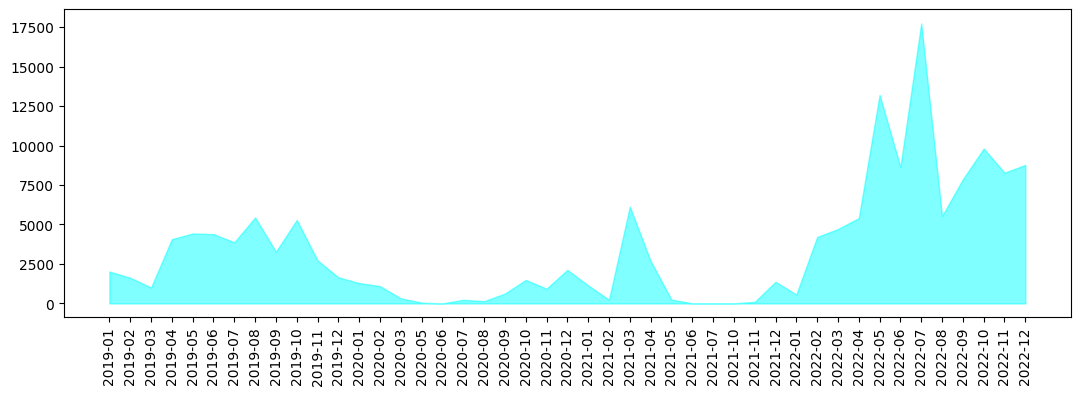

In [ ]:
#Ve bieu do mien theo thang
plt.figure(figsize=(13,4))
plt.fill_between(df_time_month['year_month'],df_time_month['total_ticket'],color='cyan',alpha=0.5)
plt.xticks(rotation=90)

In [ ]:
##Giai doan covid giua nam 2020 va 2021--> nguoi ta khong xem phim
## thieu du lieu 1 so thang

In [ ]:
start_date='2019-01-01'
end_date='2022-12-31'

date_range=pd.date_range(start=start_date,end=end_date,freq='M')
date_range
list_month=date_range.month
list_name_month=date_range.strftime('%B')
list_year=date_range.year
list_year_month=date_range.strftime('%Y-%m')

dim_time=pd.DataFrame({'month':list_month,'name_month':list_name_month,'year':list_year,'year_month':list_year_month})

/tmp/ipython-input-2325398979.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  date_range=pd.date_range(start=start_date,end=end_date,freq='M')


In [ ]:
df_time_month_dim =(pd.merge(dim_time,df_j_all,on='year_month',how='left')
    .groupby('year_month')
    .agg(total_ticket=('ticket_id','count'))

    .reset_index()
)

In [ ]:
  df_time_month_dim

,year_month,total_ticket
0,2019-01,2019
1,2019-02,1626
2,2019-03,1004
3,2019-04,4069
4,2019-05,4430
5,2019-06,4387
6,2019-07,3872
7,2019-08,5444
8,2019-09,3278
9,2019-10,5284


([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44,
  45,
  46,
  47],
 [Text(0, 0, '2019-01'),
  Text(1, 0, '2019-02'),
  Text(2, 0, '2019-03'),
  Text(3, 0, '2019-04'),
  Text(4, 0, '2019-05'),
  Text(5, 0, '2019-06'),
  Text(6, 0, '2019-07'),
  Text(7, 0, '2019-08'),
  Text(8, 0, '2019-09'),
  Text(9, 0, '2019-10'),
  Text(10, 0, '2019-11'),
  Text(11, 0, '2019-12'),
  Text(12, 0, '2020-01'),
  Text(13, 0, '2020-02'),
  Text(14, 0, '2020-03'),
  Text(15, 0, '2020-04'),
  Text(16, 0, '2020-05'),
  Text(17, 0, '2020-06'),
  Text(18, 0, '2020-07'),
  Text(19, 0, '2020-08'),
  Text(20, 0, '2020-09'),
  Text(21, 0, '2020-10'),
  Text(22, 0, '2020-11'),
  Text(23, 0, '2020-12'),
  Text(24, 0, '2021-01'),
  Text(25, 0, '2021-02'),
  Text(26, 0, '2021-03'),
  Text(27, 0, '2021-04'),
  T

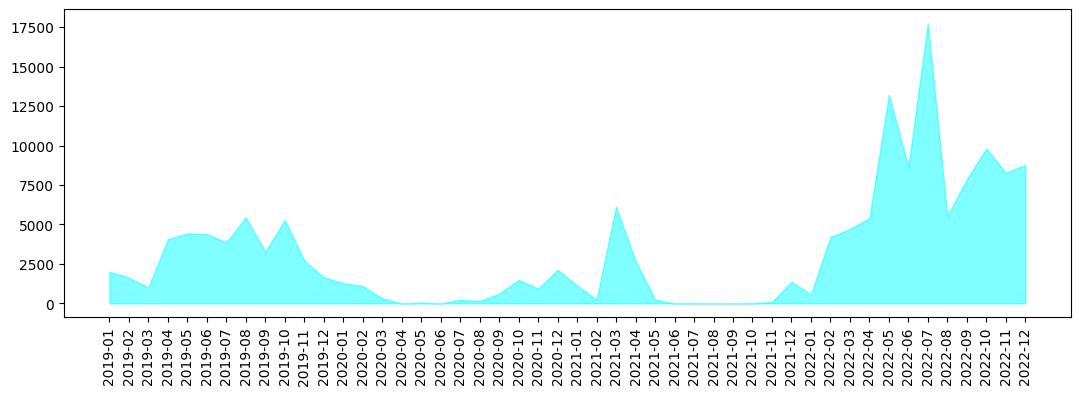

In [ ]:
plt.figure(figsize=(13,4))
plt.fill_between(df_time_month_dim['year_month'],df_time_month_dim['total_ticket'],color='cyan',alpha=0.5)
plt.xticks(rotation=90)

###Trend by weekday

In [ ]:
df_time_week=(
    df_j_all.groupby('Name_day')
    .agg(total_ticket=('ticket_id','count'))
    .reset_index()
)

In [ ]:
df_time_week

,Name_day,total_ticket
0,Friday,26438
1,Monday,16702
2,Saturday,34450
3,Sunday,26960
4,Thursday,19101
5,Tuesday,14793
6,Wednesday,16281


In [ ]:
week_order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
df_time_week['true']=pd.Categorical(df_time_week['Name_day'],categories=week_order,ordered=True)
df_time_week=df_time_week.sort_values(by='true')

In [ ]:
df_time_week

,Name_day,total_ticket,true
1,Monday,16702,Monday
5,Tuesday,14793,Tuesday
6,Wednesday,16281,Wednesday
4,Thursday,19101,Thursday
0,Friday,26438,Friday
2,Saturday,34450,Saturday
3,Sunday,26960,Sunday


In [ ]:
(df_time_week[(df_time_week['Name_day']=='Friday')|(df_time_week['Name_day']=='Saturday')|(df_time_week['Name_day']=='Sunday')]['total_ticket'].sum()
/(df_time_week['total_ticket'].sum()-
  df_time_week[(df_time_week['Name_day']=='Friday')|(df_time_week['Name_day']=='Saturday')|(df_time_week['Name_day']=='Sunday')]['total_ticket'].sum())
)

np.float64(1.3135756687650464)

([0, 1, 2, 3, 4, 5, 6],
 [Text(0, 0, 'Monday'),
  Text(1, 0, 'Tuesday'),
  Text(2, 0, 'Wednesday'),
  Text(3, 0, 'Thursday'),
  Text(4, 0, 'Friday'),
  Text(5, 0, 'Saturday'),
  Text(6, 0, 'Sunday')])

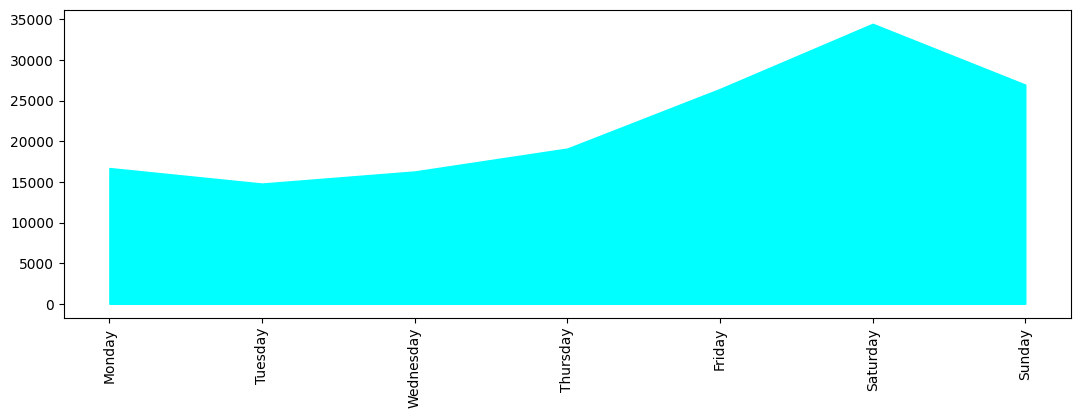

In [ ]:
plt.figure(figsize=(13,4))
plt.fill_between(df_time_week['Name_day'],df_time_week['total_ticket'],color='cyan')
plt.xticks(rotation=90)
#

###Trend by hour

In [ ]:
df_time_hour=df_j_all.groupby('hour').agg(total_ticket=('ticket_id','count')).reset_index()

In [ ]:
df_time_hour

,hour,total_ticket
0,0,2352
1,1,964
2,2,398
3,3,159
4,4,74
5,5,146
6,6,536
7,7,1473
8,8,3865
9,9,7111


([<matplotlib.axis.XTick at 0x7fb16ac5daf0>,
 [Text(0, 0, '0'),
  Text(1, 0, '1'),
  Text(2, 0, '2'),
  Text(3, 0, '3'),
  Text(4, 0, '4'),
  Text(5, 0, '5'),
  Text(6, 0, '6'),
  Text(7, 0, '7'),
  Text(8, 0, '8'),
  Text(9, 0, '9'),
  Text(10, 0, '10'),
  Text(11, 0, '11'),
  Text(12, 0, '12'),
  Text(13, 0, '13'),
  Text(14, 0, '14'),
  Text(15, 0, '15'),
  Text(16, 0, '16'),
  Text(17, 0, '17'),
  Text(18, 0, '18'),
  Text(19, 0, '19'),
  Text(20, 0, '20'),
  Text(21, 0, '21'),
  Text(22, 0, '22'),
  Text(23, 0, '23')])

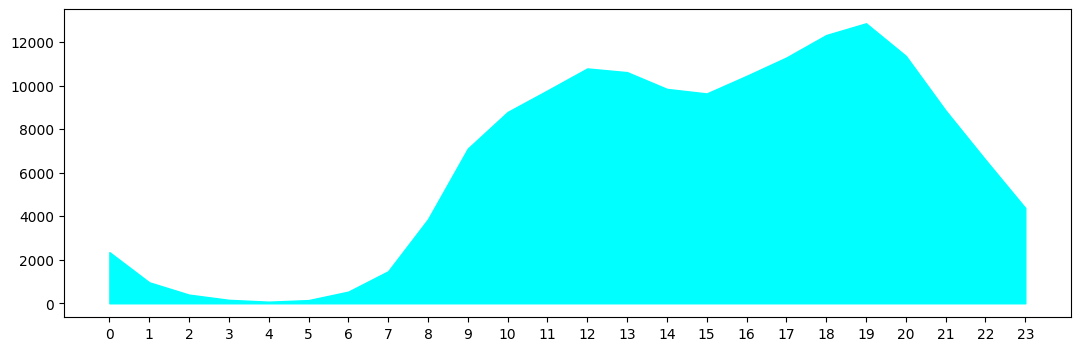

In [ ]:
plt.figure(figsize=(13,4))
plt.fill_between(df_time_hour['hour'],df_time_hour['total_ticket'],color='cyan')
x_values=[i for i in range(24)]
plt.xticks(x_values)

#

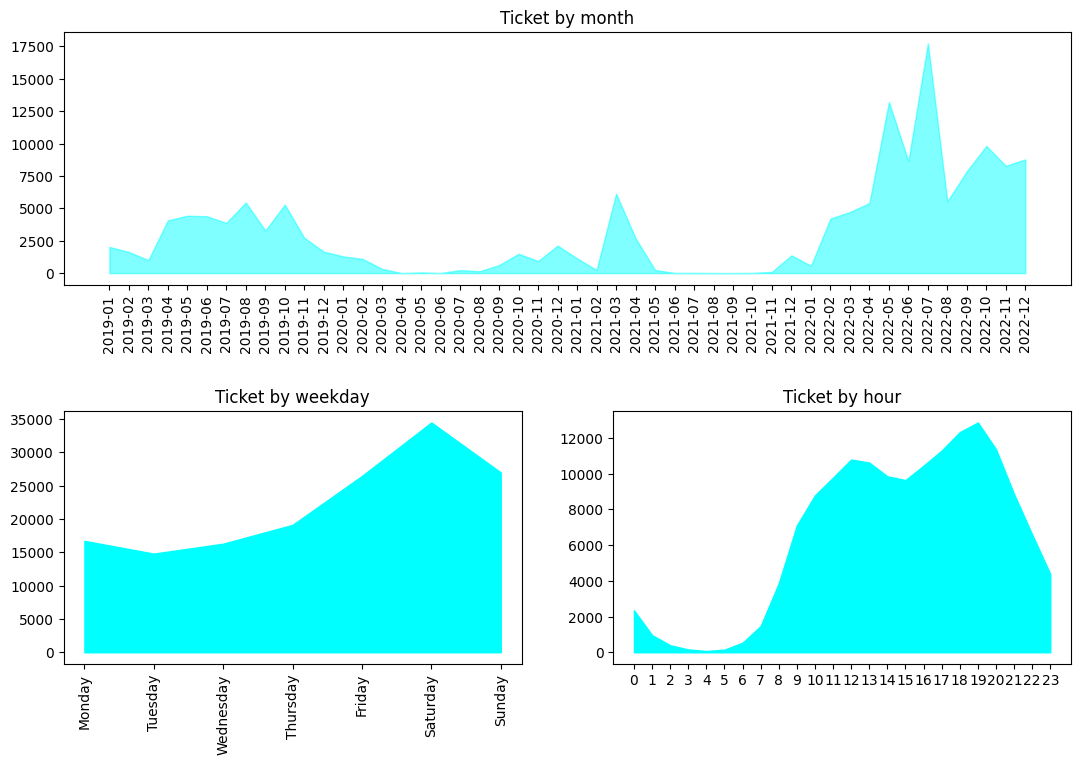

In [ ]:
#Combined
plt.figure(figsize=(13,8))
#Ticket by month
ax1=plt.subplot(2,1,1)
plt.fill_between(df_time_month_dim['year_month'],df_time_month_dim['total_ticket'],color='cyan',alpha=0.5)
plt.xticks(rotation=90)
plt.title('Ticket by month')
#Ticket by week
ax2=plt.subplot(2,2,3)
plt.fill_between(df_time_week['Name_day'],df_time_week['total_ticket'],color='cyan')
plt.xticks(rotation=90)
plt.title('Ticket by weekday')
plt.xticks(rotation=90)
#Ticket by hour
ax3=plt.subplot(2,2,4)
plt.fill_between(df_time_hour['hour'],df_time_hour['total_ticket'],color='cyan')
plt.title('Ticket by hour')
x_values=[i for i in range(24)]
plt.xticks(x_values)


plt.subplots_adjust(hspace=0.5,top=0.9)

##3.2 Factor related to the customer's purchasing process

###Payment platform

In [ ]:
df_platform =(
    df_j_all[df_j_all['platform']!='unkown']
    .groupby('platform')
    .agg(total_ticket=('ticket_id','count'))
    .reset_index()
)

Text(0.5, 1.0, 'Ticket by platform')

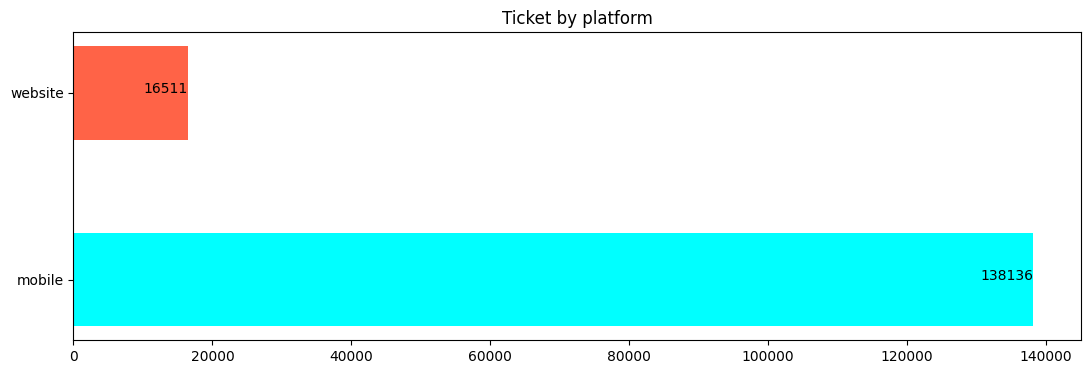

In [ ]:
plt.figure(figsize=(13,4))
plt.barh(df_platform['platform'],df_platform['total_ticket']
         ,color=df_platform['platform']
         .replace({'mobile':'cyan','website':'tomato'}),height=0.5
         )
for index , value in enumerate(df_platform['total_ticket']):
    plt.text(value,index,str(value),color='black',ha='right')
plt.title('Ticket by platform')

([<matplotlib.patches.Wedge at 0x7fb1689330e0>,
 [Text(-0.3620765534162956, -1.0387013860904282, 'mobile'),
  Text(0.362076214964405, 1.0387015040698893, 'website')],
 [Text(-0.19749630186343392, -0.5665643924129607, '89%'),
  Text(0.1974961172533118, 0.566564456765394, '11%')])

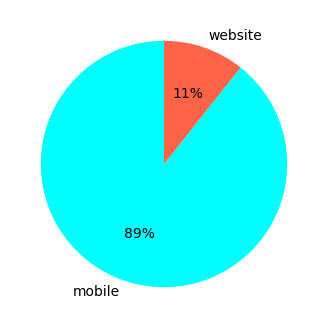

In [ ]:
plt.figure(figsize=(13,4))
plt.pie(df_platform['total_ticket']
        ,labels=df_platform['platform']
        ,colors=['cyan','tomato']
        ,autopct='%1.0f%%',startangle=90
        )


Text(0.5, 1.0, 'Ticket by platform')

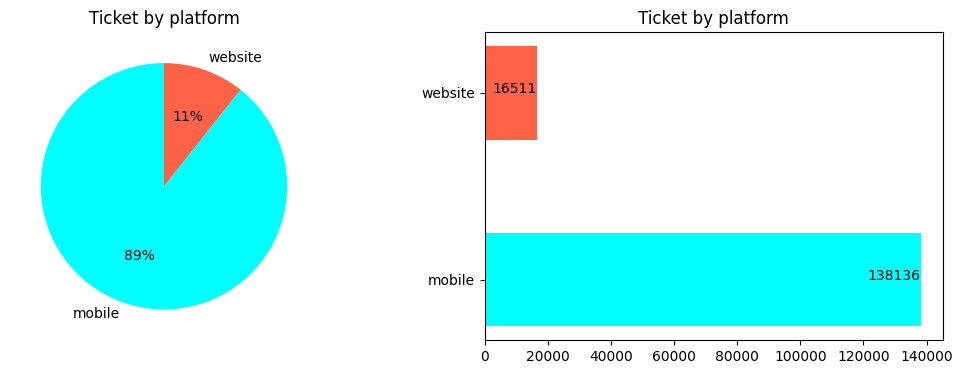

In [ ]:
plt.figure(figsize=(13,4))
ax1=plt.subplot(1,2,1)
plt.pie(df_platform['total_ticket'],labels=df_platform['platform'],colors=['cyan','tomato'],autopct='%1.0f%%',startangle=90)
plt.title('Ticket by platform')
ax2=plt.subplot(1,2,2)
plt.barh(df_platform['platform'],df_platform['total_ticket']
         ,color=df_platform['platform'].replace({'mobile':'cyan','website':'tomato'}),height=0.5)
for index , value in enumerate(df_platform['total_ticket']):
    plt.text(value,index,str(value),color='black',ha='right')
plt.title('Ticket by platform')

In [ ]:
#Theo thoi gian

df_platform_month=(
    df_j_all[df_j_all['platform']!='unkown']
    .groupby(['year_month','platform'])
    .agg(total_ticket=('ticket_id','count')).reset_index()
)

In [ ]:
df_platform_month

,year_month,platform,total_ticket
0,2019-01,mobile,2019
1,2019-02,mobile,1626
2,2019-03,mobile,1004
3,2019-04,mobile,4069
4,2019-05,mobile,4430
...,...,...,...
66,2022-10,website,1849
67,2022-11,mobile,6677
68,2022-11,website,1603
69,2022-12,mobile,6959


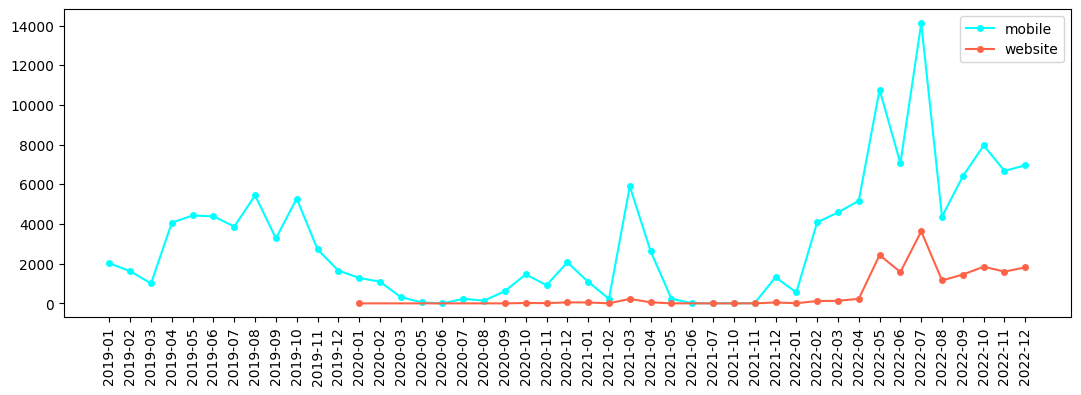

In [ ]:
#Line chart
plt.figure(figsize=(13,4))
df_mobile_line=df_platform_month[df_platform_month['platform']=='mobile']
df_website_line=df_platform_month[df_platform_month['platform']=='website']
plt.plot(df_mobile_line['year_month'],df_mobile_line['total_ticket'],color='cyan',label='mobile',marker='o',markersize=4)
plt.plot(df_website_line['year_month'],df_website_line['total_ticket'],color='tomato',label='website',marker='o',markersize=4)
plt.xticks(rotation=90)
plt.legend()

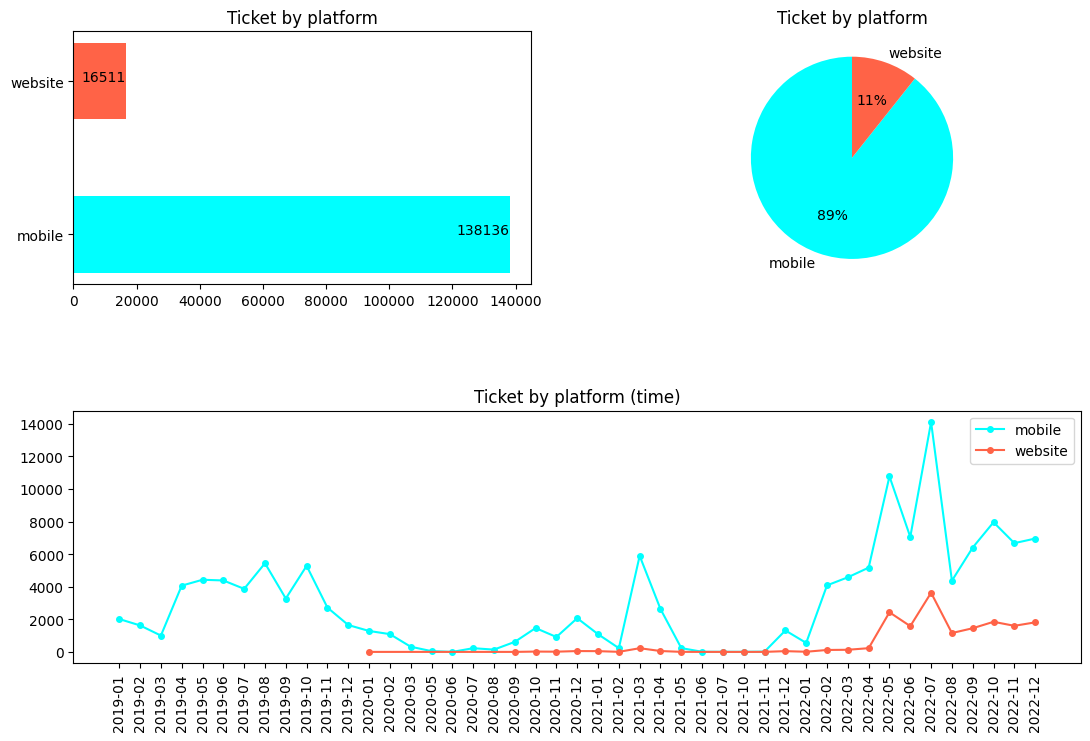

In [ ]:
plt.figure(figsize=(13,8))
ax1=plt.subplot(2,2,1)
plt.barh(df_platform['platform'],df_platform['total_ticket']
         ,color=df_platform['platform']
         .replace({'mobile':'cyan','website':'tomato'}),height=0.5
)
for index , value in enumerate(df_platform['total_ticket']):
    plt.text(value,index,str(value),color='black',ha='right')
plt.title('Ticket by platform')
ax2=plt.subplot(2,2,2)
plt.pie(df_platform['total_ticket']
        ,labels=df_platform['platform']
        ,colors=['cyan','tomato']
        ,autopct='%1.0f%%',startangle=90
)
plt.title('Ticket by platform')
ax3=plt.subplot(2,1,2)
df_mobile_line=df_platform_month[df_platform_month['platform']=='mobile']
df_website_line=df_platform_month[df_platform_month['platform']=='website']
plt.plot(df_mobile_line['year_month'],df_mobile_line['total_ticket'],color='cyan',label='mobile',marker='o',markersize=4)
plt.plot(df_website_line['year_month'],df_website_line['total_ticket'],color='tomato',label='website',marker='o',markersize=4)
plt.xticks(rotation=90)
plt.legend()
plt.title('Ticket by platform (time)')
plt.subplots_adjust(hspace=0.5,top=0.9)


###OS Version

In [ ]:
df_j_all.head()

,customer_id,usergender,dob,ticket_id,paying_method,theater_name,device_number,original_price,discount_value,final_price,time,status_id,campaign_id,movie_name,campaign_type,model,platform,description,error_group,age,month,Name_day,hour,year_month
0,100009,Male,1989-02-25,4f5200dcdcf2396b8d50ff84bf423f32,money in app,13.0,244764a57dbdeb8fe9b164847ad55183,9.90,2.10,7.80,2022-07-08 17:46:36.145,1,83330,Thor: Love And Thunder,direct discount,"iPhone13,1",mobile,Order successful,unkown,36,7,Friday,17,2022-07
1,100493,Male,1991-06-09,07abbaf28c772692f0367ad992bb3184,bank account,180.0,8fa83cf46284aafd6e5da6c96f7862b5,8.66,1.48,7.18,2022-07-15 20:44:09.952,1,83330,Thor: Love And Thunder,direct discount,browser,website,Order successful,unkown,34,7,Friday,20,2022-07
2,100596,Male,1989-05-18,1fdbeb7eceba8a27d9d985b5b70c219a,money in app,56.0,69cf9244654949047f006e441fa7a8a7,10.31,2.31,8.00,2022-07-30 11:16:55.483,1,0,Thor: Love And Thunder,unkown,unknown,mobile,Order successful,unkown,36,7,Saturday,11,2022-07
3,100852,Male,1997-08-31,7715c9955866bd296b98543412839abd,bank account,119.0,879ed11af9d6d2b5cda4d299590735a7,27.75,1.03,26.72,2022-07-04 22:33:07.458,1,85940,Thor: Love And Thunder,direct discount,devicemodel,mobile,Order successful,unkown,28,7,Monday,22,2022-07
4,100965,Male,1988-09-20,776efd7bda0b715084430e6385f67746,money in app,107.0,0a233600d993a02cc1d39fb0d87fc7de,4.33,1.03,3.30,2022-07-03 18:41:45.098,1,85940,Thor: Love And Thunder,direct discount,devicemodel,mobile,Order successful,unkown,37,7,Sunday,18,2022-07


In [ ]:
df_j_all['model'].unique()

array(['iPhone13,1', 'browser', 'unknown', ..., 'Samsung SM-J727S',
       'Zuk Z1', 'Samsung SM-N9750'], dtype=object)

In [ ]:
df_j_all['os_ver']=df_j_all['model'].apply(lambda x: 'ios'if ('iPhone'in x or 'iPod' in x)
      else 'browser' if 'browser' in x
      else 'unknown'if('unknown'in x or 'devicemodel'in x)
      else 'android & other')

In [ ]:
df_j_all.head()

,customer_id,usergender,dob,ticket_id,paying_method,theater_name,device_number,original_price,discount_value,final_price,time,status_id,campaign_id,movie_name,campaign_type,model,platform,description,error_group,age,month,Name_day,hour,year_month,os_ver
0,100009,Male,1989-02-25,4f5200dcdcf2396b8d50ff84bf423f32,money in app,13.0,244764a57dbdeb8fe9b164847ad55183,9.90,2.10,7.80,2022-07-08 17:46:36.145,1,83330,Thor: Love And Thunder,direct discount,"iPhone13,1",mobile,Order successful,unkown,36,7,Friday,17,2022-07,ios
1,100493,Male,1991-06-09,07abbaf28c772692f0367ad992bb3184,bank account,180.0,8fa83cf46284aafd6e5da6c96f7862b5,8.66,1.48,7.18,2022-07-15 20:44:09.952,1,83330,Thor: Love And Thunder,direct discount,browser,website,Order successful,unkown,34,7,Friday,20,2022-07,browser
2,100596,Male,1989-05-18,1fdbeb7eceba8a27d9d985b5b70c219a,money in app,56.0,69cf9244654949047f006e441fa7a8a7,10.31,2.31,8.00,2022-07-30 11:16:55.483,1,0,Thor: Love And Thunder,unkown,unknown,mobile,Order successful,unkown,36,7,Saturday,11,2022-07,unknown
3,100852,Male,1997-08-31,7715c9955866bd296b98543412839abd,bank account,119.0,879ed11af9d6d2b5cda4d299590735a7,27.75,1.03,26.72,2022-07-04 22:33:07.458,1,85940,Thor: Love And Thunder,direct discount,devicemodel,mobile,Order successful,unkown,28,7,Monday,22,2022-07,unknown
4,100965,Male,1988-09-20,776efd7bda0b715084430e6385f67746,money in app,107.0,0a233600d993a02cc1d39fb0d87fc7de,4.33,1.03,3.30,2022-07-03 18:41:45.098,1,85940,Thor: Love And Thunder,direct discount,devicemodel,mobile,Order successful,unkown,37,7,Sunday,18,2022-07,unknown


In [ ]:
df_os=df_j_all.groupby('os_ver').agg(total_ticket=('ticket_id','count')).sort_values('total_ticket',ascending=True).reset_index()

Text(0.5, 1.0, 'Ticket by OS')

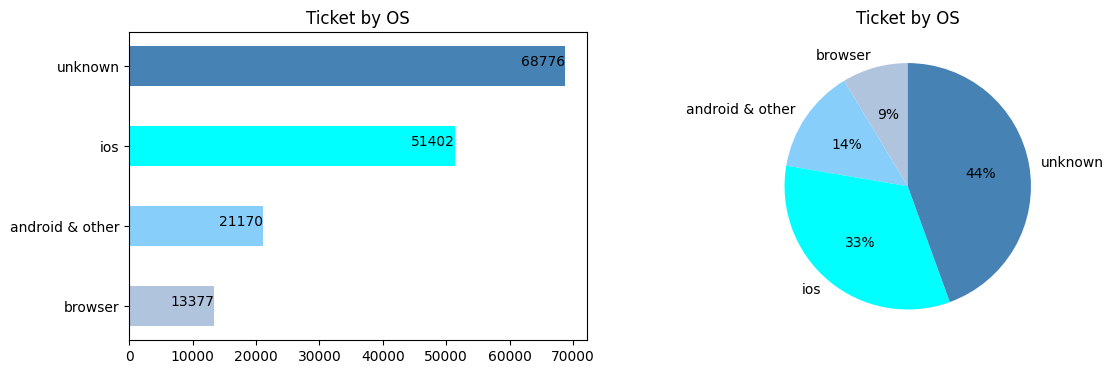

In [ ]:
plt.figure(figsize=(13,4))
ax1=plt.subplot(1,2,1)
plt.barh(df_os['os_ver'],df_os['total_ticket']
         ,color=df_os['os_ver']
         .replace({'ios':'cyan','android & other':'lightskyblue','browser':'lightsteelblue','unknown':'steelblue'}),height=0.5)
for index , value in enumerate(df_os['total_ticket']):
    plt.text(value,index,str(value),color='black',ha='right')
plt.title('Ticket by OS')
ax2=plt.subplot(1,2,2)
plt.pie(df_os['total_ticket'],labels=df_os['os_ver']
        ,colors=df_os['os_ver']
         .replace({'ios':'cyan','android & other':'lightskyblue','browser':'lightsteelblue','unknown':'steelblue'}),autopct='%1.0f%%',startangle=90)
plt.title('Ticket by OS')

In [ ]:
df_os_time=df_j_all.groupby(['year_month','os_ver']).agg(total_ticket=('ticket_id','count')).reset_index()
#

In [ ]:
df_os_time=(
    df_j_all
    .pivot_table(index='year_month',columns='os_ver',values='ticket_id',aggfunc='count')
    .reset_index()
)

In [ ]:
df_os_time.head()

os_ver,year_month,android & other,browser,ios,unknown
0,2019-01,713.0,NaN,1233.0,73.0
1,2019-02,542.0,NaN,1074.0,10.0
2,2019-03,371.0,NaN,631.0,2.0
3,2019-04,1519.0,NaN,2541.0,9.0
4,2019-05,1601.0,NaN,2826.0,3.0


([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44],
 [Text(0, 0, '2019-01'),
  Text(1, 0, '2019-02'),
  Text(2, 0, '2019-03'),
  Text(3, 0, '2019-04'),
  Text(4, 0, '2019-05'),
  Text(5, 0, '2019-06'),
  Text(6, 0, '2019-07'),
  Text(7, 0, '2019-08'),
  Text(8, 0, '2019-09'),
  Text(9, 0, '2019-10'),
  Text(10, 0, '2019-11'),
  Text(11, 0, '2019-12'),
  Text(12, 0, '2020-01'),
  Text(13, 0, '2020-02'),
  Text(14, 0, '2020-03'),
  Text(15, 0, '2020-05'),
  Text(16, 0, '2020-06'),
  Text(17, 0, '2020-07'),
  Text(18, 0, '2020-08'),
  Text(19, 0, '2020-09'),
  Text(20, 0, '2020-10'),
  Text(21, 0, '2020-11'),
  Text(22, 0, '2020-12'),
  Text(23, 0, '2021-01'),
  Text(24, 0, '2021-02'),
  Text(25, 0, '2021-03'),
  Text(26, 0, '2021-04'),
  Text(27, 0, '2021-05'),
  Text(28, 0, '2021-0

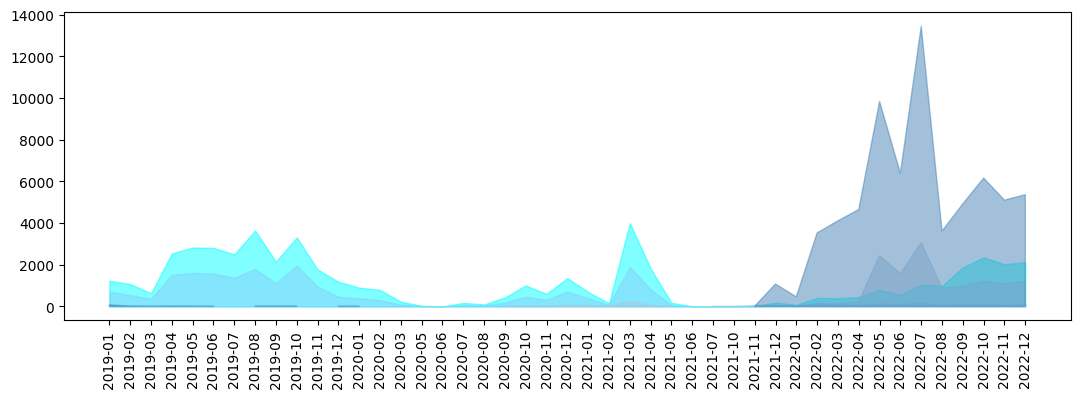

In [ ]:
plt.figure(figsize=(13,4))
plt.fill_between(df_os_time['year_month'],df_os_time['ios'],color='cyan',alpha=0.5)
plt.fill_between(df_os_time['year_month'],df_os_time['android & other'],color='lightskyblue',alpha=0.5)
plt.fill_between(df_os_time['year_month'],df_os_time['browser'],color='lightsteelblue',alpha=0.5)
plt.fill_between(df_os_time['year_month'],df_os_time['unknown'],color='steelblue',alpha=0.5)
plt.xticks(rotation=90)
#

In [ ]:
start_date='2019-01-01'
end_date='2022-12-31'
date_range=pd.date_range(start=start_date,end=end_date,freq='M')
list_month=date_range.month
list_name_month=date_range.strftime('%B')
list_year=date_range.year
list_year_month=date_range.strftime('%Y-%m')
dim_time=pd.DataFrame({'month':list_month,'name_month':list_name_month,'year':list_year,'year_month':list_year_month})

/tmp/ipython-input-1425286540.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  date_range=pd.date_range(start=start_date,end=end_date,freq='M')


In [ ]:
df_time_os=pd.merge(dim_time,df_os_time,on='year_month',how='left')

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44,
  45,
  46,
  47],
 [Text(0, 0, '2019-01'),
  Text(1, 0, '2019-02'),
  Text(2, 0, '2019-03'),
  Text(3, 0, '2019-04'),
  Text(4, 0, '2019-05'),
  Text(5, 0, '2019-06'),
  Text(6, 0, '2019-07'),
  Text(7, 0, '2019-08'),
  Text(8, 0, '2019-09'),
  Text(9, 0, '2019-10'),
  Text(10, 0, '2019-11'),
  Text(11, 0, '2019-12'),
  Text(12, 0, '2020-01'),
  Text(13, 0, '2020-02'),
  Text(14, 0, '2020-03'),
  Text(15, 0, '2020-04'),
  Text(16, 0, '2020-05'),
  Text(17, 0, '2020-06'),
  Text(18, 0, '2020-07'),
  Text(19, 0, '2020-08'),
  Text(20, 0, '2020-09'),
  Text(21, 0, '2020-10'),
  Text(22, 0, '2020-11'),
  Text(23, 0, '2020-12'),
  Text(24, 0, '2021-01'),
  Text(25, 0, '2021-02'),
  Text(26, 0, '2021-03'),
  Text(27, 0, '2021-04'),
  T

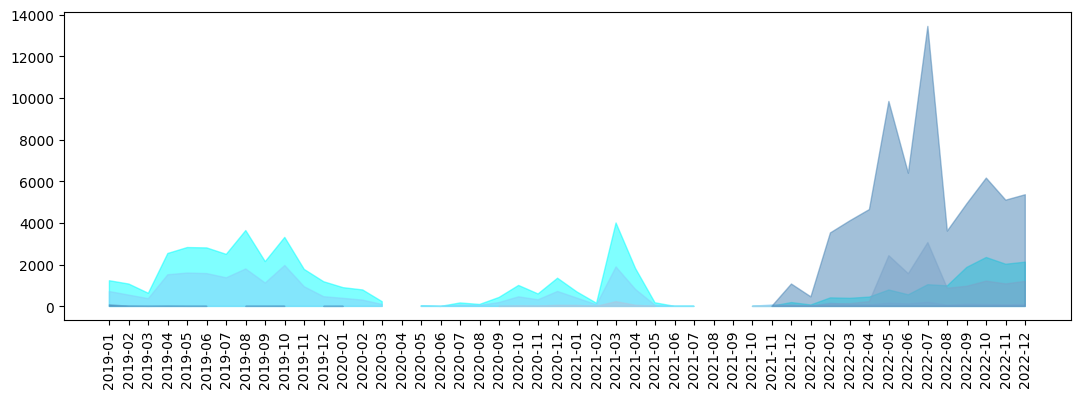

In [ ]:
plt.figure(figsize=(13,4))
plt.fill_between(df_time_os['year_month'],df_time_os['ios'],color='cyan',alpha=0.5)
plt.fill_between(df_time_os['year_month'],df_time_os['android & other'],color='lightskyblue',alpha=0.5)
plt.fill_between(df_time_os['year_month'],df_time_os['browser'],color='lightsteelblue',alpha=0.5)
plt.fill_between(df_time_os['year_month'],df_time_os['unknown'],color='steelblue',alpha=0.5)
plt.xticks(rotation=90)

/tmp/ipython-input-1921296974.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


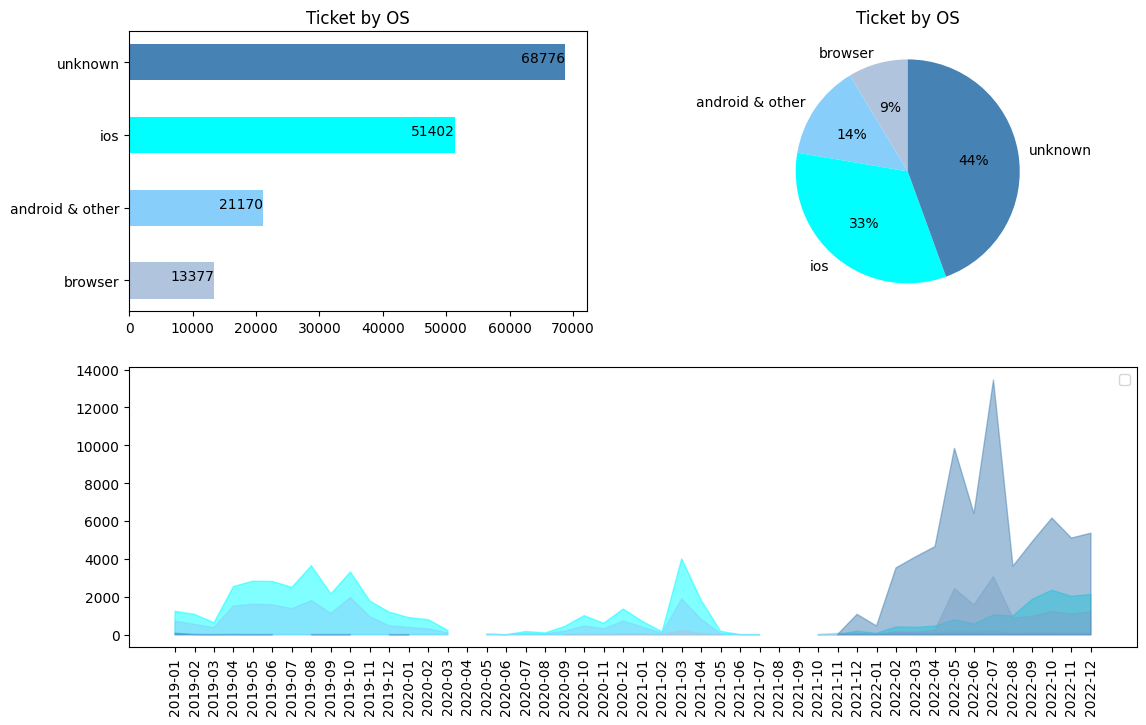

In [ ]:
#bieu dien chung
plt.figure(figsize=(13,8))
ax1=plt.subplot(2,2,1)
plt.barh(df_os['os_ver'],df_os['total_ticket']
         ,color=df_os['os_ver']
         .replace({'ios':'cyan','android & other':'lightskyblue','browser':'lightsteelblue','unknown':'steelblue'}),height=0.5)
for index , value in enumerate(df_os['total_ticket']):
    plt.text(value,index,str(value),color='black',ha='right')
plt.title('Ticket by OS')
ax2=plt.subplot(2,2,2)
plt.pie(df_os['total_ticket'],labels=df_os['os_ver']
        ,colors=df_os['os_ver']
         .replace({'ios':'cyan','android & other':'lightskyblue','browser':'lightsteelblue','unknown':'steelblue'}),autopct='%1.0f%%',startangle=90)
plt.title('Ticket by OS')
ax3=plt.subplot(2,1,2)

plt.fill_between(df_time_os['year_month'],df_time_os['ios'],color='cyan',alpha=0.5)
plt.fill_between(df_time_os['year_month'],df_time_os['android & other'],color='lightskyblue',alpha=0.5)
plt.fill_between(df_time_os['year_month'],df_time_os['browser'],color='lightsteelblue',alpha=0.5)
plt.fill_between(df_time_os['year_month'],df_time_os['unknown'],color='steelblue',alpha=0.5)
plt.xticks(rotation=90)
plt.legend()

###Payment method

In [ ]:
df_j_all.head()

,customer_id,usergender,dob,ticket_id,paying_method,theater_name,device_number,original_price,discount_value,final_price,time,status_id,campaign_id,movie_name,campaign_type,model,platform,description,error_group,age,month,Name_day,hour,year_month,os_ver
0,100009,Male,1989-02-25,4f5200dcdcf2396b8d50ff84bf423f32,money in app,13.0,244764a57dbdeb8fe9b164847ad55183,9.90,2.10,7.80,2022-07-08 17:46:36.145,1,83330,Thor: Love And Thunder,direct discount,"iPhone13,1",mobile,Order successful,unkown,36,7,Friday,17,2022-07,ios
1,100493,Male,1991-06-09,07abbaf28c772692f0367ad992bb3184,bank account,180.0,8fa83cf46284aafd6e5da6c96f7862b5,8.66,1.48,7.18,2022-07-15 20:44:09.952,1,83330,Thor: Love And Thunder,direct discount,browser,website,Order successful,unkown,34,7,Friday,20,2022-07,browser
2,100596,Male,1989-05-18,1fdbeb7eceba8a27d9d985b5b70c219a,money in app,56.0,69cf9244654949047f006e441fa7a8a7,10.31,2.31,8.00,2022-07-30 11:16:55.483,1,0,Thor: Love And Thunder,unkown,unknown,mobile,Order successful,unkown,36,7,Saturday,11,2022-07,unknown
3,100852,Male,1997-08-31,7715c9955866bd296b98543412839abd,bank account,119.0,879ed11af9d6d2b5cda4d299590735a7,27.75,1.03,26.72,2022-07-04 22:33:07.458,1,85940,Thor: Love And Thunder,direct discount,devicemodel,mobile,Order successful,unkown,28,7,Monday,22,2022-07,unknown
4,100965,Male,1988-09-20,776efd7bda0b715084430e6385f67746,money in app,107.0,0a233600d993a02cc1d39fb0d87fc7de,4.33,1.03,3.30,2022-07-03 18:41:45.098,1,85940,Thor: Love And Thunder,direct discount,devicemodel,mobile,Order successful,unkown,37,7,Sunday,18,2022-07,unknown


In [ ]:
df_method=(
    df_j_all[(df_j_all['status_id']==1)&(df_j_all['paying_method']!='other')].groupby('paying_method')
    .agg(total_ticket=('ticket_id','count'))
    .sort_values('total_ticket',ascending=False)
    .reset_index()
)

In [ ]:
df_method

,paying_method,total_ticket
0,money in app,64817
1,bank account,42057
2,credit card,15408
3,debit card,11395


In [ ]:
df_method_time=(
    df_j_all[(df_j_all['status_id']==1)&(df_j_all['paying_method']!='other')]
    .pivot_table(index='year_month',columns='paying_method',values='ticket_id',aggfunc='count')
    .reset_index()
)

Text(0.5, 1.0, 'Ticket by payment method (time)')

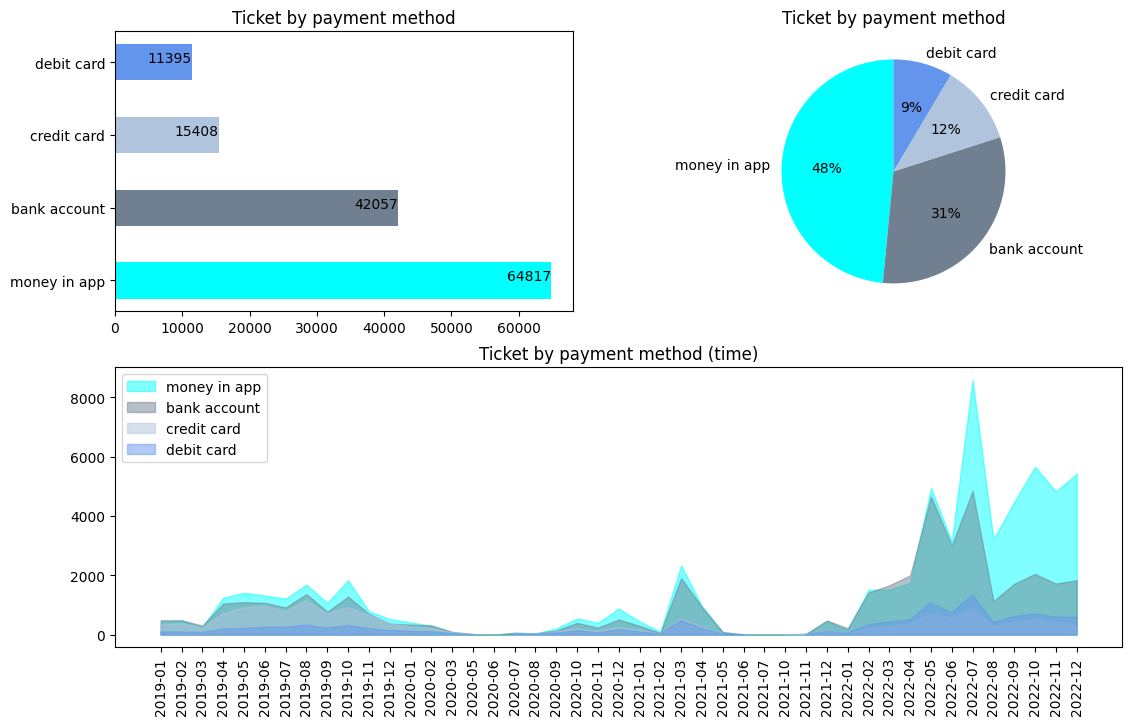

In [ ]:
plt.figure(figsize=(13,8))
ax1=plt.subplot(2,2,1)
plt.barh(df_method['paying_method'],df_method['total_ticket']
         ,color=df_method['paying_method'].replace({'money in app':'cyan','bank account':'slategrey','credit card':'lightsteelblue','debit card':'cornflowerblue'}),height=0.5)
for index , value in enumerate(df_method['total_ticket']):
    plt.text(value,index,str(value),color='black',ha='right')
    plt.title('Ticket by payment method')
ax2=plt.subplot(2,2,2)
plt.pie(df_method['total_ticket'],labels=df_method['paying_method']
        ,colors=df_method['paying_method'].replace({'money in app':'cyan','bank account':'slategrey','credit card':'lightsteelblue','debit card':'cornflowerblue'})
        ,autopct='%1.0f%%'
        ,startangle=90)
plt.title('Ticket by payment method')
ax3=plt.subplot(2,1,2)
plt.fill_between(df_method_time['year_month'],df_method_time['money in app'],color='cyan',alpha=0.5,label='money in app')
plt.fill_between(df_method_time['year_month'],df_method_time['bank account'],color='slategrey',alpha=0.5,label='bank account')
plt.fill_between(df_method_time['year_month'],df_method_time['credit card'],color='lightsteelblue',alpha=0.5,label='credit card')
plt.fill_between(df_method_time['year_month'],df_method_time['debit card'],color='cornflowerblue',alpha=0.5,label='debit card')
plt.xticks(rotation=90)
plt.legend()
plt.title('Ticket by payment method (time)')

In [ ]:
#bieu do mien 100%
df_method_time_pct=df_method_time.copy()
df_method_time_pct.fillna(0,inplace=True)
df_method_time_pct['total']=df_method_time.iloc[:,1:].sum(axis=1)

In [ ]:
df_method_time_pct
for i in df_method_time_pct.columns[1:5]:
    df_method_time_pct[i+'_pct']=df_method_time_pct[i]/df_method_time_pct['total']

In [ ]:
df_method_time_pct

paying_method,year_month,bank account,credit card,debit card,money in app,total,bank account_pct,credit card_pct,debit card_pct,money in app_pct
0,2019-01,487.0,336.0,93.0,443.0,1359.0,0.358352,0.247241,0.068433,0.325975
1,2019-02,484.0,370.0,93.0,480.0,1427.0,0.339173,0.259285,0.065172,0.336370
2,2019-03,304.0,225.0,74.0,263.0,866.0,0.351039,0.259815,0.085450,0.303695
3,2019-04,1050.0,705.0,189.0,1246.0,3190.0,0.329154,0.221003,0.059248,0.390596
4,2019-05,1092.0,903.0,212.0,1410.0,3617.0,0.301908,0.249654,0.058612,0.389826
5,2019-06,1074.0,962.0,249.0,1319.0,3604.0,0.298002,0.266926,0.069090,0.365982
6,2019-07,916.0,782.0,252.0,1215.0,3165.0,0.289415,0.247077,0.079621,0.383886
7,2019-08,1367.0,1142.0,321.0,1684.0,4514.0,0.302836,0.252991,0.071112,0.373062
8,2019-09,774.0,711.0,219.0,1068.0,2772.0,0.279221,0.256494,0.079004,0.385281
9,2019-10,1280.0,914.0,309.0,1833.0,4336.0,0.295203,0.210793,0.071264,0.422740


Text(0.5, 1.0, 'Ticket by payment method (time)')

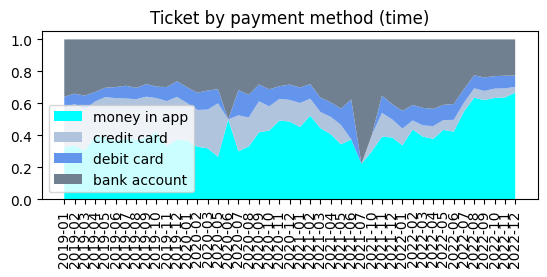

In [ ]:
ax3=plt.subplot(2,1,2)
plt.stackplot(df_method_time_pct['year_month']
              ,df_method_time_pct['money in app_pct']
              ,df_method_time_pct['credit card_pct']
              ,df_method_time_pct['debit card_pct']
              ,df_method_time_pct['bank account_pct']
              ,labels=['money in app','credit card','debit card','bank account']
              ,colors=['cyan','lightsteelblue','cornflowerblue','slategrey'])
plt.xticks(rotation=90)
plt.legend()
plt.title('Ticket by payment method (time)')

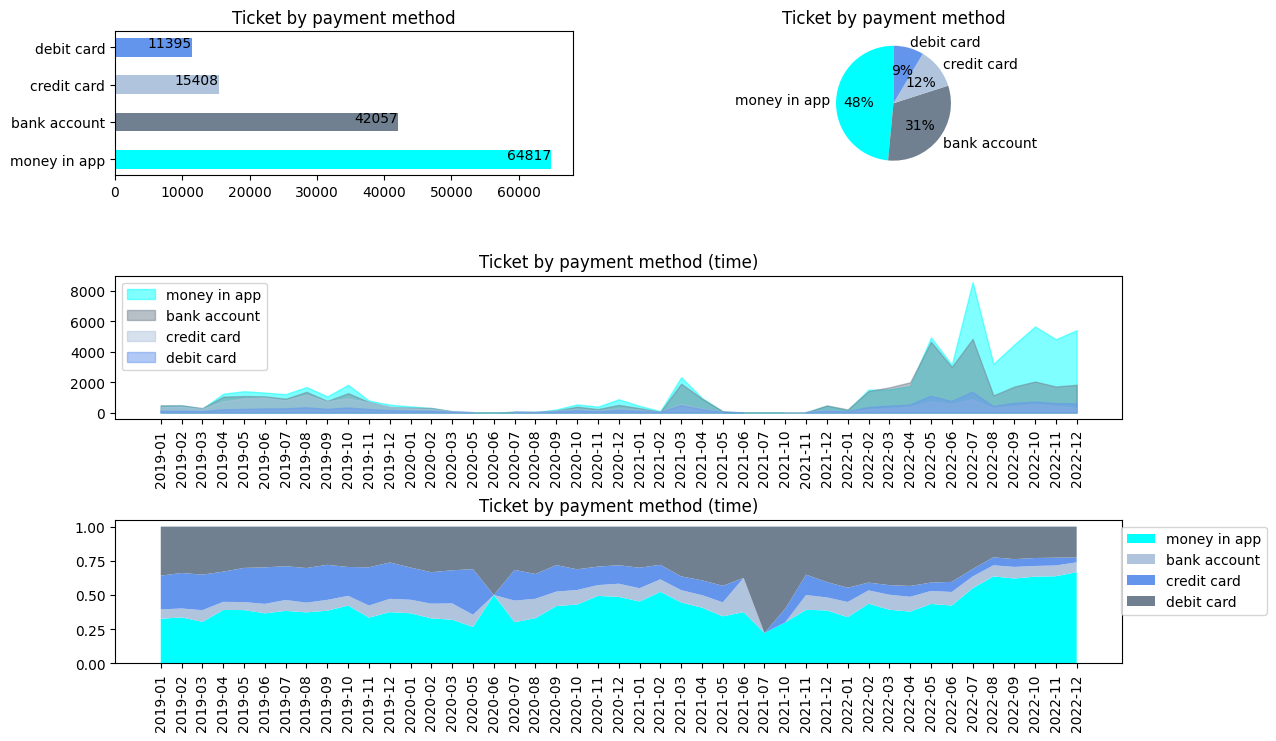

In [ ]:
plt.figure(figsize=(13,8))
ax1=plt.subplot(3,2,1)
plt.barh(df_method['paying_method'],df_method['total_ticket']
         ,color=df_method['paying_method'].replace({'money in app':'cyan','bank account':'slategrey','credit card':'lightsteelblue','debit card':'cornflowerblue'}),height=0.5)
for index , value in enumerate(df_method['total_ticket']):
    plt.text(value,index,str(value),color='black',ha='right')
    plt.title('Ticket by payment method')
ax2=plt.subplot(3,2,2)
plt.pie(df_method['total_ticket'],labels=df_method['paying_method']
        ,colors=df_method['paying_method'].replace({'money in app':'cyan','bank account':'slategrey','credit card':'lightsteelblue','debit card':'cornflowerblue'})
        ,autopct='%1.0f%%'
        ,startangle=90)
plt.title('Ticket by payment method')
ax3=plt.subplot(3,1,2)
plt.fill_between(df_method_time['year_month'],df_method_time['money in app'],color='cyan',alpha=0.5,label='money in app')
plt.fill_between(df_method_time['year_month'],df_method_time['bank account'],color='slategrey',alpha=0.5,label='bank account')
plt.fill_between(df_method_time['year_month'],df_method_time['credit card'],color='lightsteelblue',alpha=0.5,label='credit card')
plt.fill_between(df_method_time['year_month'],df_method_time['debit card'],color='cornflowerblue',alpha=0.5,label='debit card')
plt.xticks(rotation=90)
plt.legend()
plt.title('Ticket by payment method (time)')
ax4=plt.subplot(3,1,3)
plt.stackplot(df_method_time_pct['year_month']
              ,df_method_time_pct['money in app_pct']
              ,df_method_time_pct['debit card_pct']
              ,df_method_time_pct['credit card_pct']
              ,df_method_time_pct['bank account_pct']
              ,labels=['money in app','bank account','credit card','debit card']
              ,colors=['cyan','lightsteelblue','cornflowerblue','slategrey'])
plt.xticks(rotation=90)
plt.legend(loc='upper right',bbox_to_anchor=(1.15,1))

plt.title('Ticket by payment method (time)')
plt.subplots_adjust(hspace=0.7,top=0.9)

###Promotion

In [ ]:
df_j_all.head()

,customer_id,usergender,dob,ticket_id,paying_method,theater_name,device_number,original_price,discount_value,final_price,time,status_id,campaign_id,movie_name,campaign_type,model,platform,description,error_group,age,month,Name_day,hour,year_month,os_ver
0,100009,Male,1989-02-25,4f5200dcdcf2396b8d50ff84bf423f32,money in app,13.0,244764a57dbdeb8fe9b164847ad55183,9.90,2.10,7.80,2022-07-08 17:46:36.145,1,83330,Thor: Love And Thunder,direct discount,"iPhone13,1",mobile,Order successful,unkown,36,7,Friday,17,2022-07,ios
1,100493,Male,1991-06-09,07abbaf28c772692f0367ad992bb3184,bank account,180.0,8fa83cf46284aafd6e5da6c96f7862b5,8.66,1.48,7.18,2022-07-15 20:44:09.952,1,83330,Thor: Love And Thunder,direct discount,browser,website,Order successful,unkown,34,7,Friday,20,2022-07,browser
2,100596,Male,1989-05-18,1fdbeb7eceba8a27d9d985b5b70c219a,money in app,56.0,69cf9244654949047f006e441fa7a8a7,10.31,2.31,8.00,2022-07-30 11:16:55.483,1,0,Thor: Love And Thunder,unkown,unknown,mobile,Order successful,unkown,36,7,Saturday,11,2022-07,unknown
3,100852,Male,1997-08-31,7715c9955866bd296b98543412839abd,bank account,119.0,879ed11af9d6d2b5cda4d299590735a7,27.75,1.03,26.72,2022-07-04 22:33:07.458,1,85940,Thor: Love And Thunder,direct discount,devicemodel,mobile,Order successful,unkown,28,7,Monday,22,2022-07,unknown
4,100965,Male,1988-09-20,776efd7bda0b715084430e6385f67746,money in app,107.0,0a233600d993a02cc1d39fb0d87fc7de,4.33,1.03,3.30,2022-07-03 18:41:45.098,1,85940,Thor: Love And Thunder,direct discount,devicemodel,mobile,Order successful,unkown,37,7,Sunday,18,2022-07,unknown


In [ ]:
df_j_all['campaign_type'].unique()

array(['direct discount', 'unkown', 'voucher', 'reward point'],
      dtype=object)

In [ ]:
df_j_all['type']=df_j_all['campaign_type'].apply(lambda x: 'none' if x=='unkown' else 'promotion')

In [ ]:
df_j_all.head()

,customer_id,usergender,dob,ticket_id,paying_method,theater_name,device_number,original_price,discount_value,final_price,time,status_id,campaign_id,movie_name,campaign_type,model,platform,description,error_group,age,month,Name_day,hour,year_month,os_ver,type
0,100009,Male,1989-02-25,4f5200dcdcf2396b8d50ff84bf423f32,money in app,13.0,244764a57dbdeb8fe9b164847ad55183,9.90,2.10,7.80,2022-07-08 17:46:36.145,1,83330,Thor: Love And Thunder,direct discount,"iPhone13,1",mobile,Order successful,unkown,36,7,Friday,17,2022-07,ios,promotion
1,100493,Male,1991-06-09,07abbaf28c772692f0367ad992bb3184,bank account,180.0,8fa83cf46284aafd6e5da6c96f7862b5,8.66,1.48,7.18,2022-07-15 20:44:09.952,1,83330,Thor: Love And Thunder,direct discount,browser,website,Order successful,unkown,34,7,Friday,20,2022-07,browser,promotion
2,100596,Male,1989-05-18,1fdbeb7eceba8a27d9d985b5b70c219a,money in app,56.0,69cf9244654949047f006e441fa7a8a7,10.31,2.31,8.00,2022-07-30 11:16:55.483,1,0,Thor: Love And Thunder,unkown,unknown,mobile,Order successful,unkown,36,7,Saturday,11,2022-07,unknown,none
3,100852,Male,1997-08-31,7715c9955866bd296b98543412839abd,bank account,119.0,879ed11af9d6d2b5cda4d299590735a7,27.75,1.03,26.72,2022-07-04 22:33:07.458,1,85940,Thor: Love And Thunder,direct discount,devicemodel,mobile,Order successful,unkown,28,7,Monday,22,2022-07,unknown,promotion
4,100965,Male,1988-09-20,776efd7bda0b715084430e6385f67746,money in app,107.0,0a233600d993a02cc1d39fb0d87fc7de,4.33,1.03,3.30,2022-07-03 18:41:45.098,1,85940,Thor: Love And Thunder,direct discount,devicemodel,mobile,Order successful,unkown,37,7,Sunday,18,2022-07,unknown,promotion


In [ ]:
df_type=df_j_all.groupby('type').agg(total_ticket=('ticket_id','count')).reset_index()

In [ ]:
df_type_time=(
    df_j_all
    .pivot_table(index='year_month',columns='type',values='ticket_id',aggfunc='count')
    .reset_index()
)

In [ ]:
df_type_time_pct=df_type_time.copy()

In [ ]:
df_type_time_pct.fillna(0,inplace=True)
df_type_time_pct['total']=df_type_time.iloc[:,1:].sum(axis=1)
for i in df_type_time_pct.columns[1:3]:
    df_type_time_pct[i+'_pct']=df_type_time_pct[i]/df_type_time_pct['total']


In [ ]:
df_type_time_pct

type,year_month,none,promotion,total,none_pct,promotion_pct
0,2019-01,914.0,1105.0,2019.0,0.452699,0.547301
1,2019-02,1522.0,104.0,1626.0,0.936039,0.063961
2,2019-03,968.0,36.0,1004.0,0.964143,0.035857
3,2019-04,2148.0,1921.0,4069.0,0.527894,0.472106
4,2019-05,1952.0,2478.0,4430.0,0.440632,0.559368
5,2019-06,1743.0,2644.0,4387.0,0.397310,0.602690
6,2019-07,1708.0,2164.0,3872.0,0.441116,0.558884
7,2019-08,1932.0,3512.0,5444.0,0.354886,0.645114
8,2019-09,1118.0,2160.0,3278.0,0.341062,0.658938
9,2019-10,1658.0,3626.0,5284.0,0.313777,0.686223


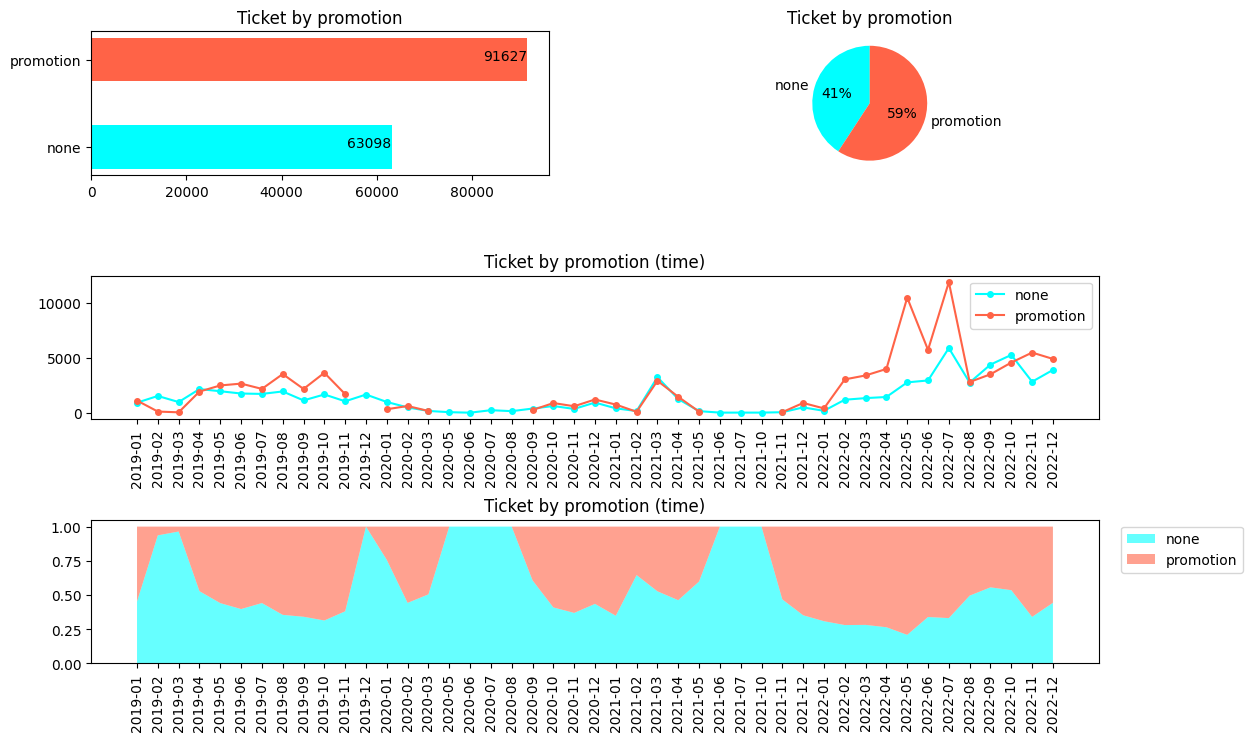

In [ ]:
plt.figure(figsize=(13,8))
ax1=plt.subplot(3,2,1)
plt.barh(df_type['type'],df_type['total_ticket']
         ,color=df_type['type'].replace({'none':'cyan','promotion':'tomato'}),height=0.5)
for index , value in enumerate(df_type['total_ticket']):
    plt.text(value,index,str(value),color='black',ha='right')
    plt.title('Ticket by promotion')
ax2=plt.subplot(3,2,2)
plt.pie(df_type['total_ticket'],labels=df_type['type']
        ,colors=['cyan','tomato']
        ,autopct='%1.0f%%'
        ,startangle=90)
plt.title('Ticket by promotion')
ax3=plt.subplot(3,1,2)
plt.plot(df_type_time['year_month'],df_type_time['none'],color='cyan',label='none',marker='o',markersize=4)
plt.plot(df_type_time['year_month'],df_type_time['promotion'],color='tomato',label='promotion',marker='o',markersize=4)
plt.xticks(rotation=90)
plt.legend()
plt.title('Ticket by promotion (time)')
ax4=plt.subplot(3,1,3)
plt.stackplot(df_type_time_pct['year_month']
              ,df_type_time_pct['none_pct']
              ,df_type_time_pct['promotion_pct']
              ,labels=['none','promotion']
              ,colors=['cyan','tomato'],alpha=0.6)
plt.xticks(rotation=90)
plt.legend(loc='upper right',bbox_to_anchor=(1.15,1))

plt.title('Ticket by promotion (time)')
plt.subplots_adjust(hspace=0.7,top=0.9)

###Which movie

In [ ]:
df_movie=(
    df_j_all[df_j_all['status_id']==1]
    .groupby('movie_name')
    .agg(total_ticket=('ticket_id','count'),
    total_customer=('customer_id','nunique'),
    revenue=('final_price','sum'))
    .sort_values('total_ticket',ascending=False)
    .reset_index()
)

In [ ]:
df_movie.head(30)

,movie_name,total_ticket,total_customer,revenue
0,Doctor Strange In The Multiverse Of Madness,8615,8409,65579.98
1,Minions: The Rise Of Gru,7224,7014,56530.93
2,Avatar: The Way Of Water,5870,5612,59830.95
3,Thor: Love And Thunder,5589,5478,43372.90
4,Peninsula,5499,5365,41208.44
5,Black Panther 2: Wakanda Forever,3847,3790,26860.28
6,Black Adam,3229,3186,23159.34
7,Avengers: Endgame,3219,3135,26690.48
8,Dad I'm Sorry,3023,2817,25863.28
9,Love Destiny,2411,2376,18345.61


In [ ]:
df_movie_top=df_movie[df_movie['total_ticket']>1000]['movie_name'].unique()

In [ ]:
df_list_movie=list(df_movie_top)
#

In [ ]:
df_list_movie

['Doctor Strange In The Multiverse Of Madness',
 'Minions: The Rise Of Gru',
 'Avatar: The Way Of Water',
 'Thor: Love And Thunder',
 'Peninsula',
 'Black Panther 2: Wakanda Forever',
 'Black Adam',
 'Avengers: Endgame',
 "Dad I'm Sorry",
 'Love Destiny',
 'You And Trinh',
 'Fast & Furious Presents: Hobbs & Shaw',
 'Emergency Declaration',
 'Jurassic World Dominion',
 'Godzilla Vs. Kong',
 'Detective Conan: The Bride Of Halloween',
 'Joker',
 'Spider-Man: No Way Home',
 'Batman',
 'Blood Moon Party',
 'Fantastic Beasts: Secrets Of Dumbledore',
 'Top Gun: Maverick',
 'Naked Truth',
 "Doraemon: Nobita's Little Star Wars 2021",
 'One Piece Film: Red',
 'Confidential Assignment 2: International',
 'Extremely Easy Job',
 'Morbius',
 'Spider-Man Far From Home',
 'Maleficent',
 'Face Off: 48h',
 'Parasite']

In [ ]:
df_movie_time=(
    df_j_all[(df_j_all['status_id']==1)&(df_j_all['movie_name'].isin(df_list_movie))]
    .pivot_table(index='year_month',columns='movie_name',values='ticket_id',aggfunc='count')
    .reset_index()
)

In [ ]:
df_movie_time

movie_name,year_month,Avatar: The Way Of Water,Avengers: Endgame,Batman,Black Adam,Black Panther 2: Wakanda Forever,Blood Moon Party,Confidential Assignment 2: International,Dad I'm Sorry,Detective Conan: The Bride Of Halloween,Doctor Strange In The Multiverse Of Madness,Doraemon: Nobita's Little Star Wars 2021,Emergency Declaration,Extremely Easy Job,Face Off: 48h,Fantastic Beasts: Secrets Of Dumbledore,Fast & Furious Presents: Hobbs & Shaw,Godzilla Vs. Kong,Joker,Jurassic World Dominion,Love Destiny,Maleficent,Minions: The Rise Of Gru,Morbius,Naked Truth,One Piece Film: Red,Parasite,Peninsula,Spider-Man Far From Home,Spider-Man: No Way Home,Thor: Love And Thunder,Top Gun: Maverick,You And Trinh
0,2019-04,NaN,2081.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2019-05,NaN,1130.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2019-06,NaN,8.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,751.0,NaN,28.0,NaN,NaN,NaN,NaN
3,2019-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,126.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,286.0,NaN,1125.0,NaN,NaN,NaN,NaN
4,2019-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1950.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2019-09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,31.0,NaN,34.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2019-10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1405.0,NaN,NaN,1008.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,2019-11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,NaN,NaN,79.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,2020-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,29.0,NaN,NaN,NaN,NaN,NaN,NaN
9,2020-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN


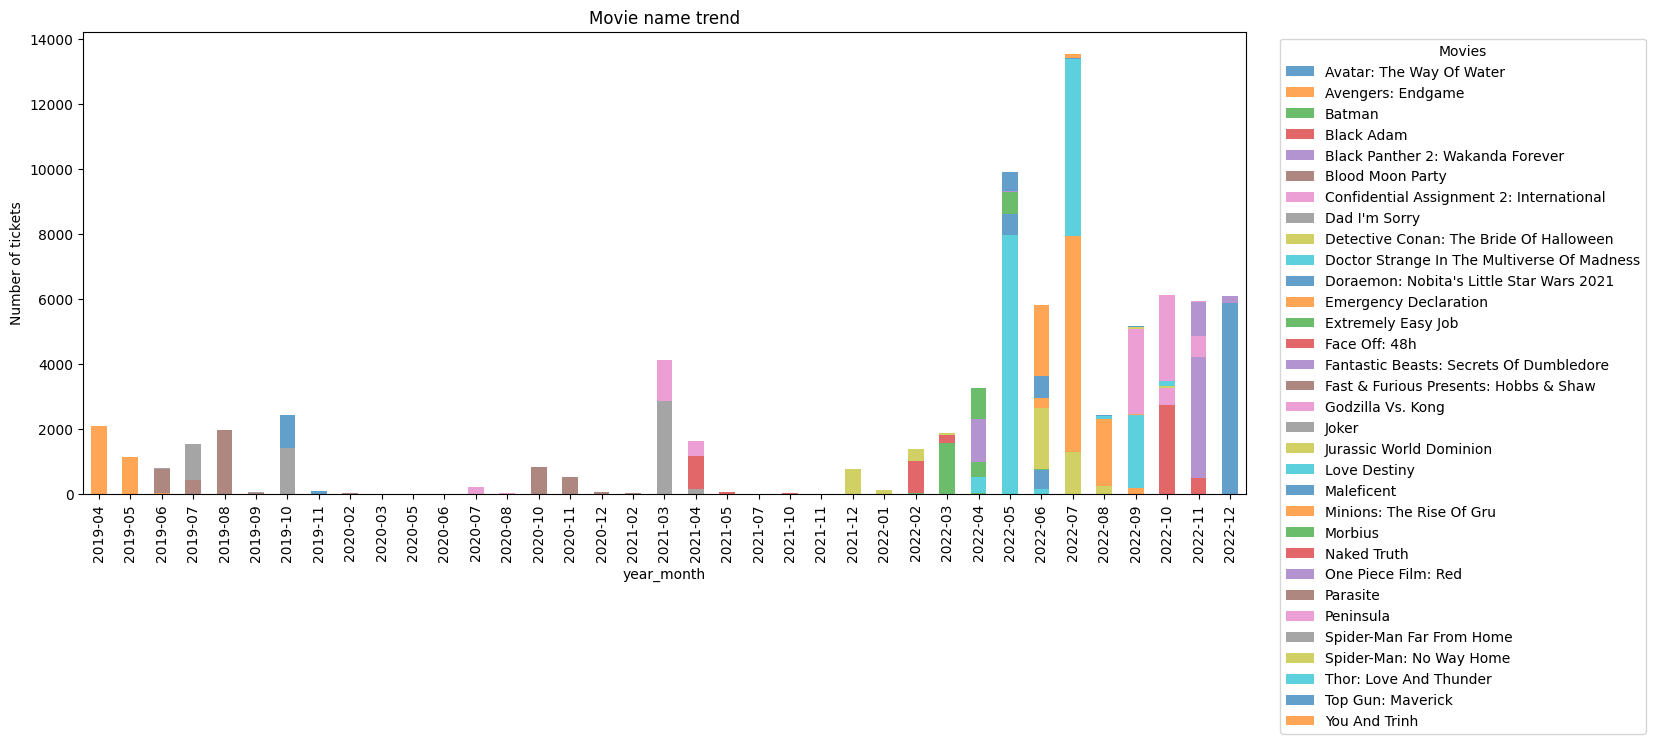

In [ ]:
#stack bar chart

ax=df_movie_time.plot(x='year_month',kind='bar',stacked=True,figsize=(15,6),alpha=0.7)
ax.set_title('Movie name trend')
ax.set_ylabel('Number of tickets')
plt.legend(title='Movies',loc='upper right',bbox_to_anchor=(1.35,1))
plt.show()

##3.4 Customer value dimension
- Mục tiêu
  + Frequency : count , day_month
  + Montary : total_money , total_discount
  + Success rate =number_success/total
  + Promotion rate=number_promotion/number_success
  + Discount rate = Sum_discount/sum_money

In [ ]:
def calc_n_promotions(x):
  return (x=='promotion').sum()

df_success_metric=(
    df_j_all[df_j_all['status_id']==1]
    .assign(date=pd.to_datetime(df_j_all['time']).dt.date)
    .groupby('customer_id')
    .agg(n_success=('ticket_id','count')
    ,s_money=('original_price','sum')
    ,s_discount=('discount_value','sum')
    ,n_day=('date','nunique')
    ,n_month=('year_month','nunique')
    ,n_promotion=('type',calc_n_promotions))
    .reset_index()
)

In [ ]:
df_success_metric.head(2)

,customer_id,n_success,s_money,s_discount,n_day,n_month,n_promotion
0,100001,1,7.42,2.06,1,1,1
1,100003,6,60.95,2.56,6,6,1


In [ ]:
#Tinh cac chi so total va failed
def calc_n_fail(x):
  return (x!=1).sum()
df_fail_metric=(
    df_j_all.groupby('customer_id')
    .agg(n_fail=('status_id',calc_n_fail)
    ,n_total=('ticket_id','count'))
    .reset_index()

)

In [ ]:
df_fail_metric.head(2)

,customer_id,n_fail,n_total
0,100001,0,1
1,100003,0,6


In [ ]:
#join 2 bang lai
df_customer_value=pd.merge(df_fail_metric,df_success_metric,on='customer_id',how='left')

In [ ]:
df_customer_value.head(2)

,customer_id,n_fail,n_total,n_success,s_money,s_discount,n_day,n_month,n_promotion
0,100001,0,1,1.0,7.42,2.06,1.0,1.0,1.0
1,100003,0,6,6.0,60.95,2.56,6.0,6.0,1.0


In [ ]:
df_customer_value.fillna(0,inplace=True)

In [ ]:
df_customer_value['success_rate']=df_customer_value['n_success']/df_customer_value['n_total']
df_customer_value['promotion_rate']=df_customer_value['n_promotion']/df_customer_value['n_success']
df_customer_value['discount_rate']=df_customer_value['s_discount']/df_customer_value['s_money']

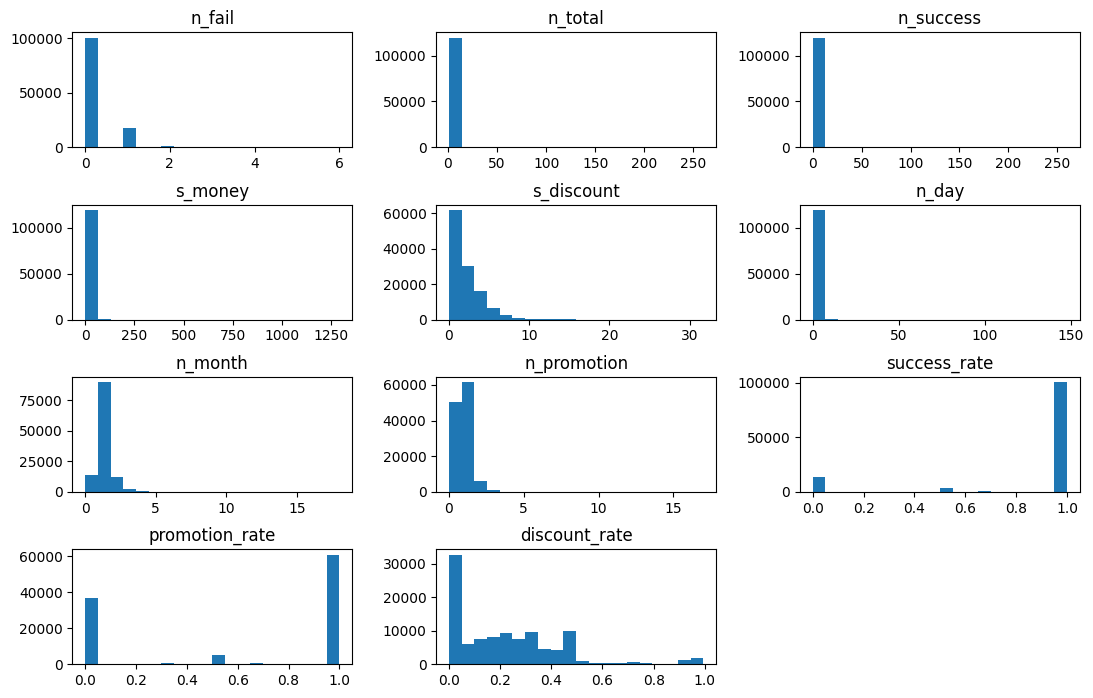

In [ ]:
df_customer_value.iloc[:,1:].hist(figsize=(13,8),grid=False,bins=20)
plt.subplots_adjust(hspace=0.5,top=0.9)
plt.show()

>- **Note**
>> - **n_total** : Hầu hết mn mua rất ít (1-2) vé nhưng có top người mua nhiều vé--> xem những người này
>> -**promotion_rate** : có 60000 chỉ tham gia promotion(100%)
>>- **n_promotion** : có hơn 600000 tham gia 1 lần (có liên quan tới **promotion_rate** hay không)
>> - **success_rate** có nhiều giao dịch không thành công ?


###Frequency and anomaly behavior

In [ ]:
df_customer_value['n_order_dis']=df_customer_value['n_success'].apply(lambda x :'more than 10'if x>=10 else str(x))

In [ ]:
df_n_diss=(
    df_customer_value.groupby('n_order_dis')
    .agg(total_customer=('customer_id','count'))
    .reset_index()
)

In [ ]:
df_n_diss

,n_order_dis,total_customer
0,0.0,13701
1,1.0,87921
2,2.0,12902
3,3.0,3145
4,4.0,1017
5,5.0,380
6,6.0,168
7,7.0,92
8,8.0,47
9,9.0,30


Text(0.5, 1.0, 'Frequency of order')

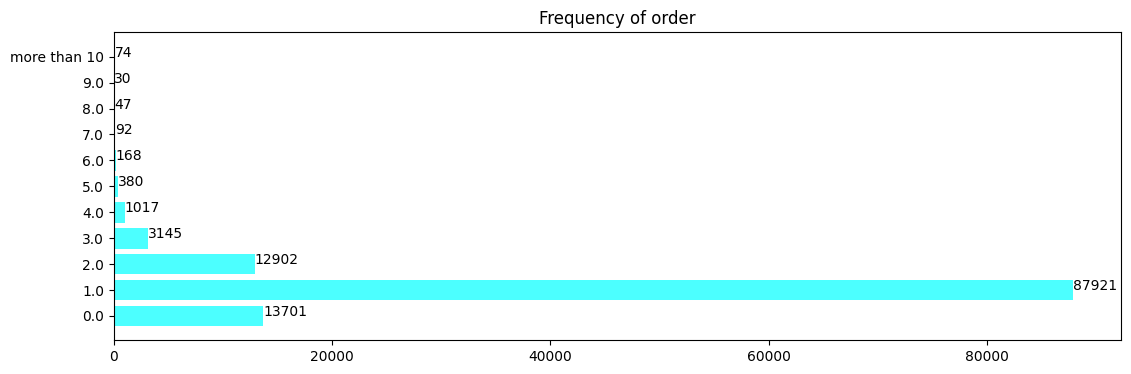

In [ ]:
plt.figure(figsize=(13,4))
plt.barh(df_n_diss['n_order_dis'],df_n_diss['total_customer']
       ,color='cyan',alpha=0.7)
for index , value in enumerate(df_n_diss['total_customer']):
    plt.text(value,index,str(value),color='black',ha='left')
plt.title('Frequency of order')

In [ ]:
#neu ho mua don 1 luc ---> bat thuong
#neu ho mua dan trai ---> binh thuong

In [ ]:
df_customer_value.sort_values('n_success',ascending=False).head(20)

,customer_id,n_fail,n_total,n_success,s_money,s_discount,n_day,n_month,n_promotion,success_rate,promotion_rate,discount_rate,n_order_dis
2686,102948,0,260,260.0,1291.25,3.38,148.0,18.0,1.0,1.000000,0.003846,0.002618,more than 10
48948,153588,1,108,107.0,434.59,0.00,77.0,14.0,0.0,0.990741,0.000000,0.000000,more than 10
10604,111644,0,104,104.0,581.70,18.52,85.0,18.0,9.0,1.000000,0.086538,0.031838,more than 10
15783,117362,1,104,103.0,744.86,8.62,79.0,15.0,6.0,0.990385,0.058252,0.011573,more than 10
16687,118349,3,83,80.0,344.56,4.21,62.0,17.0,1.0,0.963855,0.012500,0.012218,more than 10
20907,122962,1,77,76.0,447.00,1.86,45.0,9.0,3.0,0.987013,0.039474,0.004161,more than 10
72718,179471,1,69,68.0,375.91,7.14,51.0,9.0,4.0,0.985507,0.058824,0.018994,more than 10
62432,168132,3,69,66.0,249.03,0.00,59.0,14.0,0.0,0.956522,0.000000,0.000000,more than 10
111563,222641,0,51,51.0,240.84,2.31,41.0,11.0,3.0,1.000000,0.058824,0.009591,more than 10
53097,158089,2,53,51.0,245.14,1.69,40.0,14.0,2.0,0.962264,0.039216,0.006894,more than 10


In [ ]:
list_customer_massive=list(df_customer_value[df_customer_value['n_success']>=30]['customer_id'].unique())

In [ ]:
list_customer_massive

['102948',
 '103035',
 '103347',
 '108110',
 '108162',
 '108729',
 '111644',
 '114205',
 '117140',
 '117362',
 '117475',
 '118349',
 '122962',
 '131905',
 '153124',
 '153588',
 '158089',
 '168132',
 '179471',
 '222641',
 '226527',
 '226886']

In [ ]:
df_customer_massive_pivot=(
    df_j_all[(df_j_all['status_id']==1)&(df_j_all['customer_id'].isin(list_customer_massive))]
    .pivot_table(index='year_month',columns='customer_id',values='ticket_id',aggfunc='count')
    .reset_index()

)

In [ ]:
df_customer_massive_pivot.fillna(0,inplace=True)

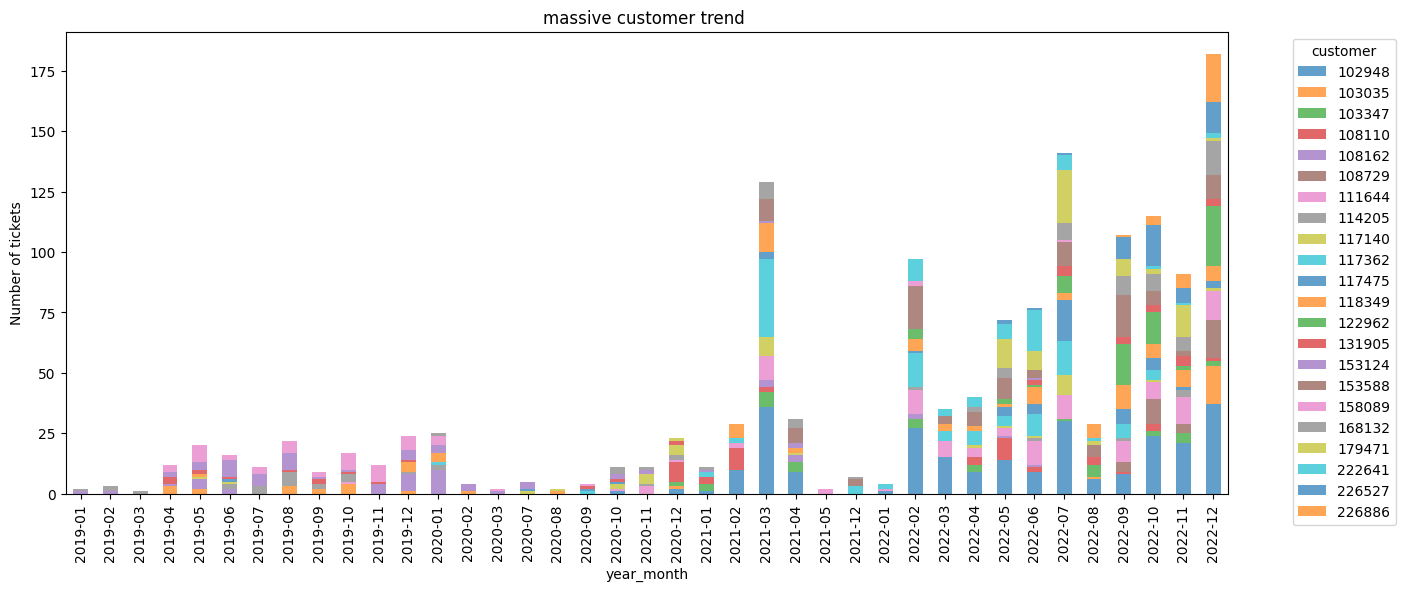

In [ ]:
ax=df_customer_massive_pivot.plot(x='year_month',kind='bar',stacked=True,figsize=(15,6),alpha=0.7)
ax.set_title('massive customer trend ')
ax.set_ylabel('Number of tickets')
plt.legend(title='customer',loc='upper right',bbox_to_anchor=(1.15,1))
plt.show()

>- **Note**
>> - Số lượng mua vé >=30 trên 1 lần có sự dàn trải --> không có hiện tượng spam vé
>>- Chưa có dấu hiệu bất thường

###Massive Promotion

In [ ]:
df_customer_value['n_promo_dis']=df_customer_value['n_promotion'].apply(lambda x :'more than 10'if x>=10 else str(x))

In [ ]:
df_promo_diss=(
    df_customer_value.groupby('n_promo_dis')
    .agg(total_customer=('customer_id','count'))
    .reset_index()

)

In [ ]:
df_promo_diss.head(12)

,n_promo_dis,total_customer
0,0.0,50498
1,1.0,61334
2,2.0,6264
3,3.0,1042
4,4.0,230
5,5.0,74
6,6.0,19
7,7.0,10
8,8.0,2
9,9.0,2


Text(0.5, 1.0, 'Frequency of promotion')

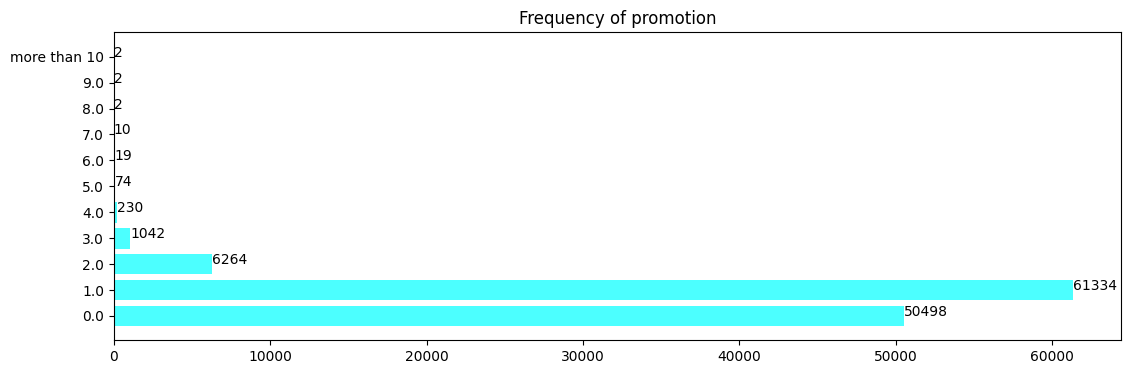

In [ ]:
plt.figure(figsize=(13,4))
plt.barh(df_promo_diss['n_promo_dis'],df_promo_diss['total_customer'],color='cyan',alpha=0.7)
for index , value in enumerate(df_promo_diss['total_customer']):
    plt.text(value,index,str(value),color='black',ha='left')
plt.title('Frequency of promotion')
#

>>- 60% KH join chương trình khuyến mãi
>>- 90% KH hưởng 1 lần duy nhất
>>>- Khách hàng hưởng 1 lần rồi rời đi
>>>- Chương trình chỉ dành cho new customer

In [ ]:
#loai khuyen mai KH dang dung la gi
##danh gia loai khuyen mai KH dung
df_type_group=(
    df_j_all[(df_j_all['status_id']==1)&(df_j_all['type']=='promotion')]
    .groupby('campaign_type')
    .agg(total=('ticket_id','count'))
    .reset_index()
)

In [ ]:
df_type_group

,campaign_type,total
0,direct discount,68449
1,reward point,3150
2,voucher,6924


In [ ]:
#Tinh ti le KM chi tiết cho từng nhóm KH
df_n_success=(
    df_j_all[(df_j_all['status_id']==1)&(df_j_all['type']=='promotion')]
    .groupby('customer_id')
    .agg(n_promotion=('ticket_id','count'))
    .reset_index()

)

In [ ]:
df_n_pivot=(
    df_j_all[(df_j_all['status_id']==1)&(df_j_all['type']=='promotion')]
    .pivot_table(index='customer_id',columns='campaign_type',values='ticket_id',aggfunc='count')
    .reset_index()
)

In [ ]:
df_n_pivot

campaign_type,customer_id,direct discount,reward point,voucher
0,100001,NaN,NaN,1.0
1,100003,1.0,NaN,NaN
2,100005,NaN,NaN,1.0
3,100007,1.0,NaN,NaN
4,100009,7.0,NaN,NaN
...,...,...,...,...
68974,231393,NaN,NaN,1.0
68975,231395,1.0,NaN,NaN
68976,231397,NaN,NaN,1.0
68977,231398,NaN,NaN,1.0


In [ ]:
df_n_join=(
    pd.merge(df_n_success,df_n_pivot,on='customer_id',how='inner').groupby('n_promotion')
    .agg(n_cus=('customer_id','count')
    ,n_voucher=('voucher','sum')
    ,n_direct_discount=('direct discount','sum')
    ,n_reward_point=('reward point','sum')

    )
    .reset_index()

)

In [ ]:
df_n_join

,n_promotion,n_cus,n_voucher,n_direct_discount,n_reward_point
0,1,61334,5358.0,53098.0,2878.0
1,2,6264,1091.0,11222.0,215.0
2,3,1042,293.0,2788.0,45.0
3,4,230,87.0,827.0,6.0
4,5,74,43.0,323.0,4.0
5,6,19,12.0,102.0,0.0
6,7,10,14.0,54.0,2.0
7,8,2,2.0,14.0,0.0
8,9,2,6.0,12.0,0.0
9,10,1,1.0,9.0,0.0


In [ ]:
df_n_join['total']=df_n_join.iloc[:,2:].sum(axis=1)

In [ ]:
df_n_join

,n_promotion,n_cus,n_voucher,n_direct_discount,n_reward_point,total
0,1,61334,5358.0,53098.0,2878.0,61334.0
1,2,6264,1091.0,11222.0,215.0,12528.0
2,3,1042,293.0,2788.0,45.0,3126.0
3,4,230,87.0,827.0,6.0,920.0
4,5,74,43.0,323.0,4.0,370.0
5,6,19,12.0,102.0,0.0,114.0
6,7,10,14.0,54.0,2.0,70.0
7,8,2,2.0,14.0,0.0,16.0
8,9,2,6.0,12.0,0.0,18.0
9,10,1,1.0,9.0,0.0,10.0


In [ ]:
for i in df_n_join.columns[2:5]:
    df_n_join[i+'_pct']=df_n_join[i]/df_n_join['total']

In [ ]:
df_n_join

,n_promotion,n_cus,n_voucher,n_direct_discount,n_reward_point,total,n_voucher_pct,n_direct_discount_pct,n_reward_point_pct
0,1,61334,5358.0,53098.0,2878.0,61334.0,0.087358,0.865719,0.046923
1,2,6264,1091.0,11222.0,215.0,12528.0,0.087085,0.895754,0.017162
2,3,1042,293.0,2788.0,45.0,3126.0,0.093730,0.891875,0.014395
3,4,230,87.0,827.0,6.0,920.0,0.094565,0.898913,0.006522
4,5,74,43.0,323.0,4.0,370.0,0.116216,0.872973,0.010811
5,6,19,12.0,102.0,0.0,114.0,0.105263,0.894737,0.000000
6,7,10,14.0,54.0,2.0,70.0,0.200000,0.771429,0.028571
7,8,2,2.0,14.0,0.0,16.0,0.125000,0.875000,0.000000
8,9,2,6.0,12.0,0.0,18.0,0.333333,0.666667,0.000000
9,10,1,1.0,9.0,0.0,10.0,0.100000,0.900000,0.000000


In [ ]:
#heatmap table
format_dict={'total':'{:.0f}','n_voucher_pct':'{:.0%}','n_direct_discount_pct':'{:.0%}','n_reward_point_pct':'{:.0%}'}
(
    df_n_join
    .style
    .background_gradient(subset=['n_voucher_pct','n_direct_discount_pct','n_reward_point_pct'],cmap='Blues')
    .format(format_dict)

)


,n_promotion,n_cus,n_voucher,n_direct_discount,n_reward_point,total,n_voucher_pct,n_direct_discount_pct,n_reward_point_pct
0,1,61334,5358.000000,53098.000000,2878.000000,61334,9%,87%,5%
1,2,6264,1091.000000,11222.000000,215.000000,12528,9%,90%,2%
2,3,1042,293.000000,2788.000000,45.000000,3126,9%,89%,1%
3,4,230,87.000000,827.000000,6.000000,920,9%,90%,1%
4,5,74,43.000000,323.000000,4.000000,370,12%,87%,1%
5,6,19,12.000000,102.000000,0.000000,114,11%,89%,0%
6,7,10,14.000000,54.000000,2.000000,70,20%,77%,3%
7,8,2,2.000000,14.000000,0.000000,16,12%,88%,0%
8,9,2,6.000000,12.000000,0.000000,18,33%,67%,0%
9,10,1,1.000000,9.000000,0.000000,10,10%,90%,0%


In [ ]:
df_n_join.drop(columns=df_n_join.columns[2:5],inplace=True)

>- **Note**
>>- 99% KH dùng direct discount
>>- Đánh giá về Retention

##3.5 Cohort Analysis-Customer Retention

In [ ]:
#dua vao thoi diem lan dau chuyen doi khach hang
from operator import attrgetter
import matplotlib.colors as mcolors
import seaborn as sns

In [ ]:
df_selected_time=df_j_all[(df_j_all['time']<'2020-01-01')&(df_j_all['status_id']==1)]

In [ ]:
df_selected_time

,customer_id,usergender,dob,ticket_id,paying_method,theater_name,device_number,original_price,discount_value,final_price,time,status_id,campaign_id,movie_name,campaign_type,model,platform,description,error_group,age,month,Name_day,hour,year_month,os_ver,type
11327,100009,Male,1989-02-25,9e3e753f70aede1c6dcc577ce563eef1,credit card,74.0,3cac5d2e2eb76525aecea5c2ab46b3d9,9.07,2.56,6.51,2019-11-09 16:19:41.008,1,25680,Doctor Sleep,direct discount,"iPhone10,2",mobile,Order successful,unkown,36,11,Saturday,16,2019-11,ios,promotion
11328,101892,Female,1986-10-19,74a0ac9b7c60d2e7d3664686c3342c00,money in app,79.0,fe9a5c91e224f005a8be1c62923548d8,9.07,2.56,6.51,2019-11-16 16:35:02.953,1,25690,Doctor Sleep,direct discount,Samsung SM-N935F,mobile,Order successful,unkown,38,11,Saturday,16,2019-11,android & other,promotion
11329,105574,Male,1935-01-01,4a653fb01188cfaefe7e3731de2648de,credit card,43.0,99b47df3cdeecb3dec4da6c18b916dd0,9.07,2.56,6.51,2019-11-09 18:10:13.461,1,25680,Doctor Sleep,direct discount,"iPhone9,2",mobile,Order successful,unkown,90,11,Saturday,18,2019-11,ios,promotion
11332,111681,Not verify,1970-01-01,f075d68aa14bc424e3d9ca7904f900a5,credit card,123.0,a43fb711603d5f2be7001397d280e413,8.66,2.10,6.56,2019-11-16 22:02:42.851,1,25690,Doctor Sleep,direct discount,HTC HTC_U-3u,mobile,Order successful,unkown,55,11,Saturday,22,2019-11,android & other,promotion
11333,116896,Male,1990-08-30,747efd023e43617ca96e127c8af625b8,money in app,72.0,ac219f148fe5a9653b48ce64b41625b7,6.19,0.00,6.19,2019-11-13 17:32:32.892,1,0,Doctor Sleep,unkown,OnePlus HD1900,mobile,Order successful,unkown,35,11,Wednesday,17,2019-11,android & other,none
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
154563,158089,Male,1989-05-27,bf76ce68307c1f10be4107a3bff5f316,credit card,22.0,41bb18cbb49861f16cee7307639ea760,2.27,0.00,2.27,2019-08-23 16:52:42.965,1,0,Detective Conan: The Fist Of Blue Sapphire,unkown,"iPhone11,6",mobile,Order successful,unkown,36,8,Friday,16,2019-08,ios,none
154564,158089,Male,1989-05-27,684456be12d7851f0ff1b1e57b344acf,credit card,22.0,41bb18cbb49861f16cee7307639ea760,2.27,0.00,2.27,2019-08-23 16:55:25.219,1,0,Detective Conan: The Fist Of Blue Sapphire,unkown,"iPhone11,6",mobile,Order successful,unkown,36,8,Friday,16,2019-08,ios,none
154565,164430,Female,1994-01-29,b73bb8c17717fe678a21b4794c503b22,money in app,92.0,ba1e0710c1597c7efa76d803afaf00c9,9.07,6.64,2.43,2019-08-24 13:01:42.116,1,19800,Detective Conan: The Fist Of Blue Sapphire,direct discount,"iPhone8,2",mobile,Order successful,unkown,31,8,Saturday,13,2019-08,ios,promotion
154566,166271,Female,1997-09-04,f9e59e112d1088ab79d1810d02822673,bank account,92.0,822ecd00ffeced141228ade3256e8ca7,2.06,0.00,2.06,2019-08-26 07:42:28.969,1,0,Detective Conan: The Fist Of Blue Sapphire,unkown,"iPhone7,2",mobile,Order successful,unkown,28,8,Monday,7,2019-08,ios,none


In [ ]:
df_selected_time['first_month']=(
    df_selected_time
    .groupby('customer_id')['time'].transform('min').dt.to_period('M')
)
df_selected_time['current_month']=df_selected_time['time'].dt.to_period('M')
df_selected_time['subsequent_month']=(df_selected_time['current_month']-df_selected_time['first_month']).apply(attrgetter('n'))


/tmp/ipython-input-1396845825.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_selected_time['first_month']=(
/tmp/ipython-input-1396845825.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_selected_time['current_month']=df_selected_time['time'].dt.to_period('M')
/tmp/ipython-input-1396845825.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas

In [ ]:
df_selected_time.head()

,customer_id,usergender,dob,ticket_id,paying_method,theater_name,device_number,original_price,discount_value,final_price,time,status_id,campaign_id,movie_name,campaign_type,model,platform,description,error_group,age,month,Name_day,hour,year_month,os_ver,type,first_month,current_month,subsequent_month
11327,100009,Male,1989-02-25,9e3e753f70aede1c6dcc577ce563eef1,credit card,74.0,3cac5d2e2eb76525aecea5c2ab46b3d9,9.07,2.56,6.51,2019-11-09 16:19:41.008,1,25680,Doctor Sleep,direct discount,"iPhone10,2",mobile,Order successful,unkown,36,11,Saturday,16,2019-11,ios,promotion,2019-04,2019-11,7
11328,101892,Female,1986-10-19,74a0ac9b7c60d2e7d3664686c3342c00,money in app,79.0,fe9a5c91e224f005a8be1c62923548d8,9.07,2.56,6.51,2019-11-16 16:35:02.953,1,25690,Doctor Sleep,direct discount,Samsung SM-N935F,mobile,Order successful,unkown,38,11,Saturday,16,2019-11,android & other,promotion,2019-08,2019-11,3
11329,105574,Male,1935-01-01,4a653fb01188cfaefe7e3731de2648de,credit card,43.0,99b47df3cdeecb3dec4da6c18b916dd0,9.07,2.56,6.51,2019-11-09 18:10:13.461,1,25680,Doctor Sleep,direct discount,"iPhone9,2",mobile,Order successful,unkown,90,11,Saturday,18,2019-11,ios,promotion,2019-11,2019-11,0
11332,111681,Not verify,1970-01-01,f075d68aa14bc424e3d9ca7904f900a5,credit card,123.0,a43fb711603d5f2be7001397d280e413,8.66,2.10,6.56,2019-11-16 22:02:42.851,1,25690,Doctor Sleep,direct discount,HTC HTC_U-3u,mobile,Order successful,unkown,55,11,Saturday,22,2019-11,android & other,promotion,2019-11,2019-11,0
11333,116896,Male,1990-08-30,747efd023e43617ca96e127c8af625b8,money in app,72.0,ac219f148fe5a9653b48ce64b41625b7,6.19,0.00,6.19,2019-11-13 17:32:32.892,1,0,Doctor Sleep,unkown,OnePlus HD1900,mobile,Order successful,unkown,35,11,Wednesday,17,2019-11,android & other,none,2019-11,2019-11,0


In [ ]:
df_cohort=df_selected_time.groupby(['first_month','current_month','subsequent_month'])['customer_id'].nunique().reset_index()

In [ ]:
df_cohort


,first_month,current_month,subsequent_month,customer_id
0,2019-01,2019-01,0,1348
1,2019-01,2019-02,1,50
2,2019-01,2019-03,2,35
3,2019-01,2019-04,3,26
4,2019-01,2019-05,4,25
...,...,...,...,...
73,2019-10,2019-11,1,137
74,2019-10,2019-12,2,71
75,2019-11,2019-11,0,1522
76,2019-11,2019-12,1,48


In [ ]:
df_cohort_pivot=(
    df_cohort.pivot_table(index='first_month',columns='subsequent_month',values='customer_id')

)

In [ ]:
df_cohort_pivot

subsequent_month,0,1,2,3,4,5,6,7,8,9,10,11
first_month,,,,,,,,,,,,
2019-01,1348.0,50.0,35.0,26.0,25.0,33.0,36.0,29.0,18.0,35.0,21.0,20.0
2019-02,1293.0,58.0,88.0,64.0,78.0,50.0,58.0,30.0,46.0,29.0,35.0,NaN
2019-03,745.0,51.0,48.0,49.0,33.0,33.0,30.0,34.0,23.0,14.0,NaN,NaN
2019-04,2922.0,101.0,103.0,87.0,92.0,66.0,96.0,63.0,42.0,NaN,NaN,NaN
2019-05,3226.0,145.0,118.0,129.0,90.0,93.0,90.0,62.0,NaN,NaN,NaN,NaN
2019-06,3062.0,131.0,151.0,98.0,133.0,114.0,63.0,NaN,NaN,NaN,NaN,NaN
2019-07,2611.0,121.0,79.0,99.0,78.0,40.0,NaN,NaN,NaN,NaN,NaN,NaN
2019-08,3735.0,112.0,155.0,106.0,64.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-09,2169.0,117.0,67.0,39.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
cohort_size=df_cohort_pivot.iloc[:,0]
retention_matrix=df_cohort_pivot.divide(cohort_size,axis=0)

In [ ]:
retention_matrix

subsequent_month,0,1,2,3,4,5,6,7,8,9,10,11
first_month,,,,,,,,,,,,
2019-01,1.0,0.037092,0.025964,0.019288,0.018546,0.024481,0.026706,0.021513,0.013353,0.025964,0.015579,0.014837
2019-02,1.0,0.044857,0.068059,0.049497,0.060325,0.038670,0.044857,0.023202,0.035576,0.022428,0.027069,NaN
2019-03,1.0,0.068456,0.064430,0.065772,0.044295,0.044295,0.040268,0.045638,0.030872,0.018792,NaN,NaN
2019-04,1.0,0.034565,0.035250,0.029774,0.031485,0.022587,0.032854,0.021561,0.014374,NaN,NaN,NaN
2019-05,1.0,0.044947,0.036578,0.039988,0.027898,0.028828,0.027898,0.019219,NaN,NaN,NaN,NaN
2019-06,1.0,0.042782,0.049314,0.032005,0.043436,0.037231,0.020575,NaN,NaN,NaN,NaN,NaN
2019-07,1.0,0.046342,0.030257,0.037917,0.029874,0.015320,NaN,NaN,NaN,NaN,NaN,NaN
2019-08,1.0,0.029987,0.041499,0.028380,0.017135,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-09,1.0,0.053942,0.030890,0.017981,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


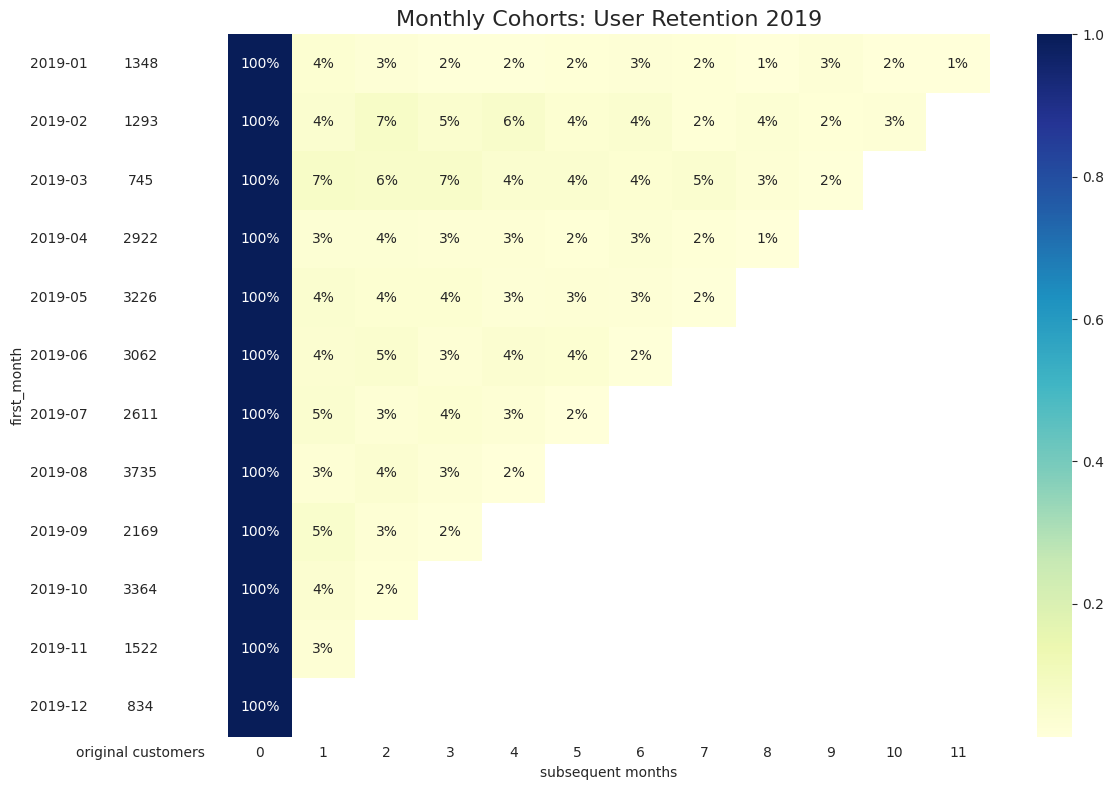

In [ ]:
with sns.axes_style("white"):
    fig, ax = plt.subplots(1, 2, figsize=(12, 8), sharey=True,
                           gridspec_kw={'width_ratios': [1, 11]})

    # retention matrix
    sns.heatmap(retention_matrix,
                mask=retention_matrix.isnull(),
                annot=True,
                fmt='.0%',
                cmap='YlGnBu',
                ax=ax[1])
    ax[1].set_title('Monthly Cohorts: User Retention 2019', fontsize=16)
    ax[1].set(xlabel='subsequent months', ylabel='')

    # cohort size
    cohort_size_df = pd.DataFrame(cohort_size).rename(columns={0: 'original customers'})
    white_cmap = mcolors.ListedColormap(['white'])
    sns.heatmap(cohort_size_df,
                annot=True,
                cbar=False,
                fmt='g',
                cmap=white_cmap,
                alpha=0.5,
                ax=ax[0])

    fig.tight_layout()

In [ ]:
df_selected_time=df_j_all[(df_j_all['time']>'2022-01-01')&(df_j_all['status_id']==1)]

In [ ]:
df_selected_time['first_month']=(
    df_selected_time
    .groupby('customer_id')['time'].transform('min').dt.to_period('M')
)
df_selected_time['current_month']=df_selected_time['time'].dt.to_period('M')
df_selected_time['subsequent_month']=(df_selected_time['current_month']-df_selected_time['first_month']).apply(attrgetter('n'))


/tmp/ipython-input-1396845825.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_selected_time['first_month']=(
/tmp/ipython-input-1396845825.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_selected_time['current_month']=df_selected_time['time'].dt.to_period('M')
/tmp/ipython-input-1396845825.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas

In [ ]:
df_cohort=df_selected_time.groupby(['first_month','current_month','subsequent_month'])['customer_id'].nunique().reset_index()

In [ ]:
df_cohort_pivot=(
    df_cohort.pivot_table(index='first_month',columns='subsequent_month',values='customer_id')

)

In [ ]:
cohort_size=df_cohort_pivot.iloc[:,0]
retention_matrix=df_cohort_pivot.divide(cohort_size,axis=0)

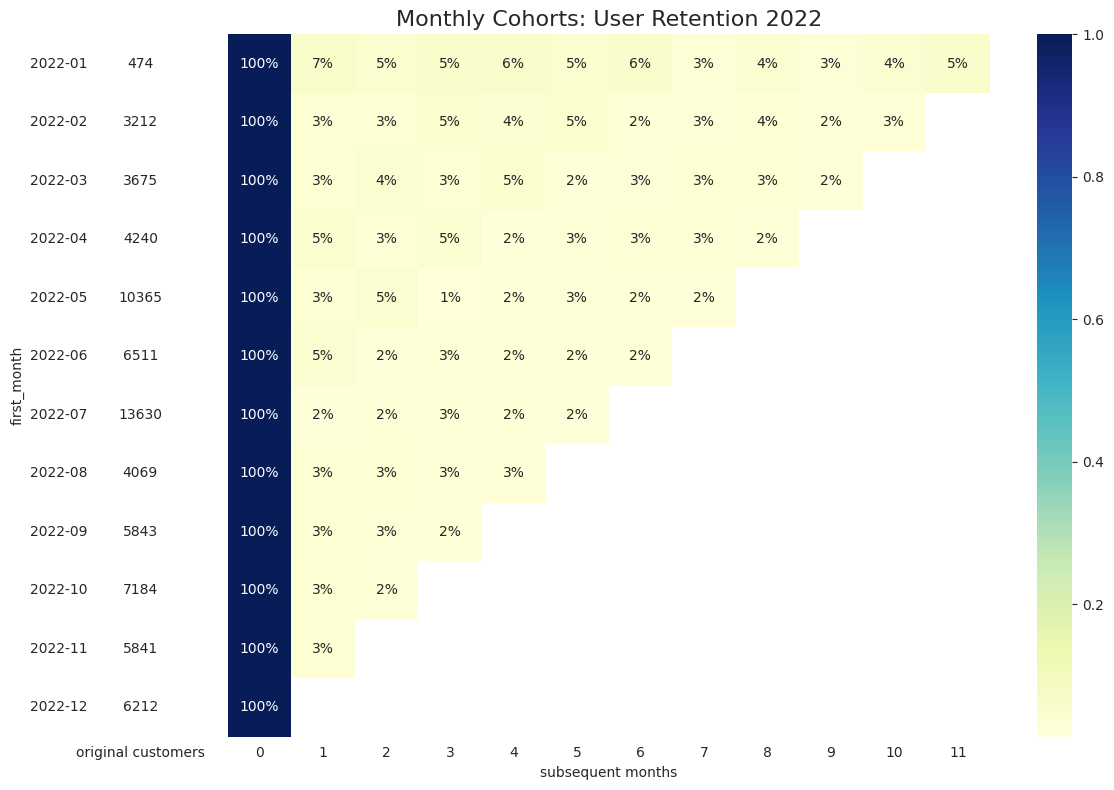

In [ ]:
with sns.axes_style("white"):
    fig, ax = plt.subplots(1, 2, figsize=(12, 8), sharey=True,
                           gridspec_kw={'width_ratios': [1, 11]})

    # retention matrix
    sns.heatmap(retention_matrix,
                mask=retention_matrix.isnull(),
                annot=True,
                fmt='.0%',
                cmap='YlGnBu',
                ax=ax[1])
    ax[1].set_title('Monthly Cohorts: User Retention 2022', fontsize=16)
    ax[1].set(xlabel='subsequent months', ylabel='')

    # cohort size
    cohort_size_df = pd.DataFrame(cohort_size).rename(columns={0: 'original customers'})
    white_cmap = mcolors.ListedColormap(['white'])
    sns.heatmap(cohort_size_df,
                annot=True,
                cbar=False,
                fmt='g',
                cmap=white_cmap,
                alpha=0.5,
                ax=ax[0])

    fig.tight_layout()

###Compare : Retention of promotion customers & organic customers

In [ ]:
df_pie_promo=(
    df_j_all[(df_j_all['status_id']==1)&(df_j_all['time']>'2022-01-01')]
    .groupby('type')
    .agg(total_ticket=('ticket_id','count'))
    .reset_index()
)


In [ ]:
df_pie_promo

,type,total_ticket
0,none,31655
1,promotion,52045


Text(0.5, 1.0, 'percentage by type')

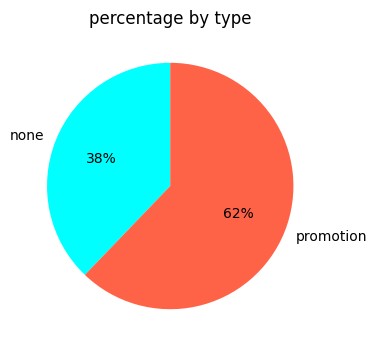

In [ ]:
plt.figure(figsize=(13,4))
plt.pie(df_pie_promo['total_ticket'],labels=df_pie_promo['type']
        ,colors=['cyan','tomato']
        ,autopct='%1.0f%%'
        ,startangle=90)
plt.title('percentage by type')

In [ ]:
df_pie_promoz=(
    df_j_all[(df_j_all['status_id']==1)&(df_j_all['time']>'2022-01-01')]
    .groupby('type')
    .agg(total_cus=('customer_id','nunique'))
    .reset_index()
)
df_pie_promoz

,type,total_cus
0,none,27672
1,promotion,47507


In [ ]:
#Phan biet nhom promotion va organic (first order
#danh so thu tu cac don hang cua tung khach hang
df_check=df_j_all[(df_j_all['status_id']==1)&(df_j_all['time']>'2022-01-01')][['customer_id','ticket_id','time','type']]
df_check['number_order']=df_check.groupby('customer_id')['time'].rank(method='dense')

In [ ]:
df_check.head(10)

,customer_id,ticket_id,time,type,number_order
0,100009,4f5200dcdcf2396b8d50ff84bf423f32,2022-07-08 17:46:36.145,promotion,1.0
1,100493,07abbaf28c772692f0367ad992bb3184,2022-07-15 20:44:09.952,promotion,1.0
2,100596,1fdbeb7eceba8a27d9d985b5b70c219a,2022-07-30 11:16:55.483,none,1.0
3,100852,7715c9955866bd296b98543412839abd,2022-07-04 22:33:07.458,promotion,1.0
4,100965,776efd7bda0b715084430e6385f67746,2022-07-03 18:41:45.098,promotion,1.0
5,101001,284d3fe54b25bb1877106b3335b82333,2022-07-08 13:44:11.611,promotion,1.0
7,101502,63e2018e8d2a277b31c37094d3325ccd,2022-07-17 17:41:47.684,promotion,1.0
8,101788,e3a7ee66aa7633c807af92fd60938d2a,2022-07-06 20:54:39.705,promotion,1.0
9,101905,bac5700d10216de03474a15d415c63f7,2022-07-09 10:59:58.494,promotion,1.0
10,102751,3f09045d8bf7b8260ead55ab22bfd4ac,2022-07-22 20:44:05.361,promotion,1.0


In [ ]:
df_check[(df_check['type']=='promotion')&(df_check['number_order']==1)]['customer_id'].nunique()

46189

In [ ]:
46189/47507

0.9722567200623066

In [ ]:
#co 97 % KH den tu promotion trong nhom KH den tu promotion

In [ ]:
df_first_tran_list=df_check[(df_check['type']=='promotion')&(df_check['number_order']==1)]['customer_id']

In [ ]:
df_first_tran_list.drop_duplicates(inplace=True)

/tmp/ipython-input-579457341.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_first_tran_list.drop_duplicates(inplace=True)


In [ ]:
df_return=pd.merge(df_check,df_first_tran_list,on='customer_id',how='right')

In [ ]:
(
    df_return[df_return['number_order']==2]['customer_id'].nunique()
    /
    df_return['customer_id'].nunique()
)

0.1308969668102795

In [ ]:
#13% KH quay lai ke tu lan dau tham gia promotion ti le giu chan = 13%


In [ ]:
df_first_ogn_list=df_check[(df_check['type']=='none')&(df_check['number_order']==1)]['customer_id']
df_first_ogn_list.drop_duplicates(inplace=True)
df_return_org=pd.merge(df_check,df_first_ogn_list,on='customer_id',how='right')


/tmp/ipython-input-3673187097.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_first_ogn_list.drop_duplicates(inplace=True)


In [ ]:
(
    df_return_org[df_return_org['number_order']==2]['customer_id'].nunique()
    /
    df_return_org['customer_id'].nunique()

)

0.12195316551641601

In [ ]:
#Nhoms khach hang co lan dau la organic ti le quay lai la 12%

>**Notes:**

>- **97%** promotion 2022 là dành cho NEW CUSTOMERS, tuy nhiên  
>- Chỉ có **13%** quay trở lại lần sau, trong khi tỷ lệ này của nhóm organic là **12%**  

>--> Công ty đang chú trọng acquire new customers nhưng chưa đẩy mạnh việc giữ chân và duy trì lượng KH cũ.

##3.6 Success Rate

###Overview

In [ ]:
def cacl_n_success(x):
  return(x==1).sum()
df_sr=(
    df_j_all
    .groupby('year_month')
    .agg(n_success=('status_id',cacl_n_success)
    ,n_total=('ticket_id','count'))
    .assign(success_rate=lambda x:x['n_success']*100/x['n_total'])
    .reset_index()
)

In [ ]:
df_sr

,year_month,n_success,n_total,success_rate
0,2019-01,1359,2019,67.310550
1,2019-02,1427,1626,87.761378
2,2019-03,866,1004,86.254980
3,2019-04,3190,4069,78.397641
4,2019-05,3617,4430,81.647856
5,2019-06,3604,4387,82.151812
6,2019-07,3165,3872,81.740702
7,2019-08,4514,5444,82.916973
8,2019-09,2772,3278,84.563758
9,2019-10,4336,5284,82.059046


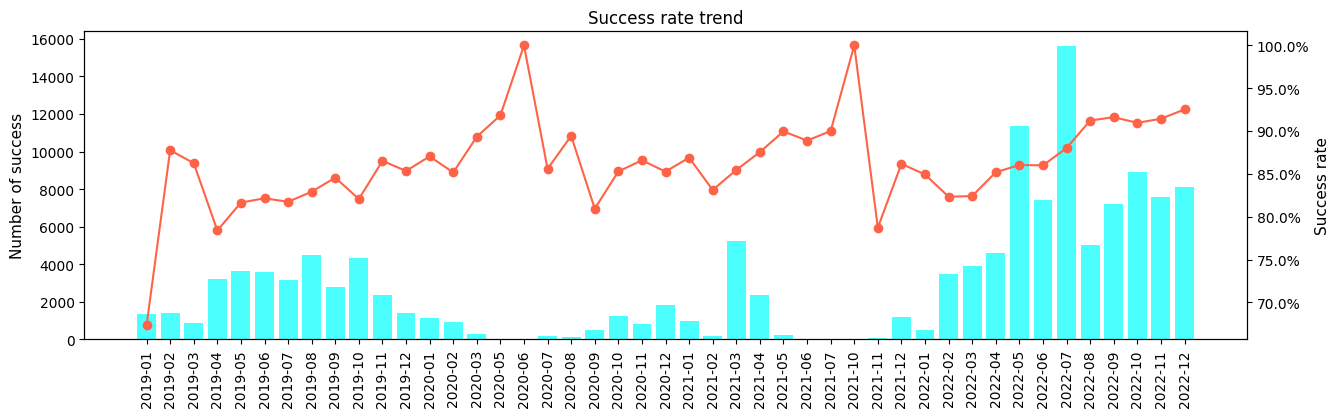

In [ ]:
from matplotlib.ticker import PercentFormatter
fig,ax1=plt.subplots(figsize=(15,4))
ax1.bar(df_sr['year_month'],df_sr['n_success'],color='cyan',alpha=0.7)
ax1.set_ylabel('Number of success',fontsize=11)
plt.xticks(rotation=90)

ax2=ax1.twinx()
ax2.plot(df_sr['year_month'],df_sr['success_rate'],color='tomato',marker='o')
ax2.set_ylabel('Success rate',fontsize=11)
ax2.yaxis.set_major_formatter(PercentFormatter())
plt.title('Success rate trend')
plt.show()


###Error Trend

In [ ]:
df_error_group=(
    df_j_all[df_j_all['status_id']!=1]
    .groupby(['year_month','error_group'])
    .agg(total=('ticket_id','count'))
    .sort_values('year_month',ascending=True)
    .reset_index()

)

In [ ]:
df_error_group

,year_month,error_group,total
0,2019-01,customer,291
1,2019-01,external,369
2,2019-02,customer,66
3,2019-02,external,133
4,2019-03,customer,44
...,...,...,...
100,2022-11,customer,146
101,2022-11,internal,1
102,2022-12,external,535
103,2022-12,customer,113


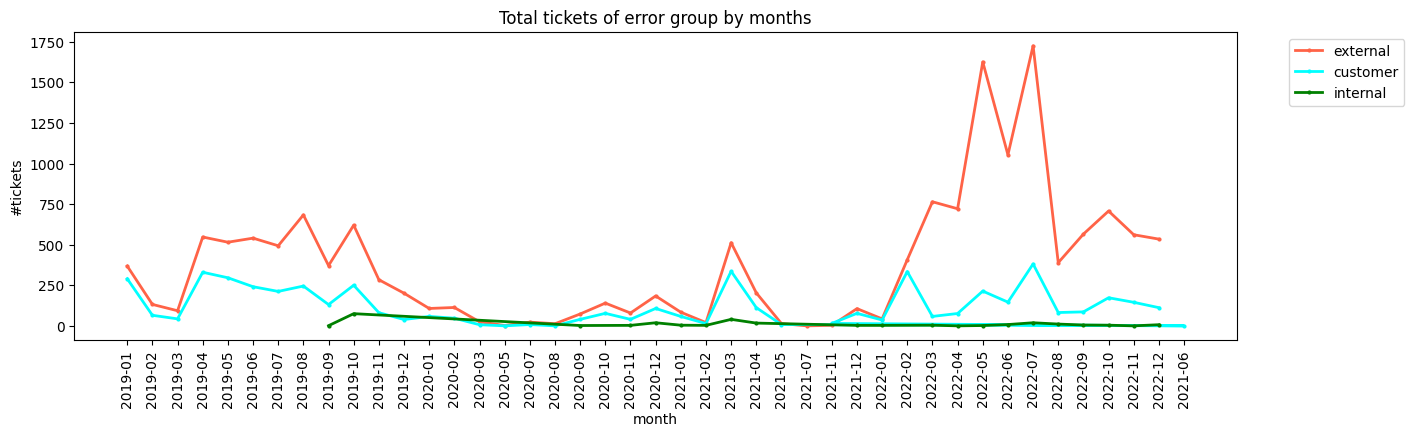

In [ ]:
# Phân bổ nhóm lỗi:
error_color_pairs = [('external', 'tomato'), ('customer', 'cyan'), ('internal', 'green')]

plt.figure(figsize=(15, 4))

for error, color in error_color_pairs:
    df_err_line = df_error_group[df_error_group['error_group'] == error]
    plt.plot(df_err_line['year_month'], df_err_line['total'],
             label=error, marker='o', color=color, linewidth=2, markersize=2)

plt.title('Total tickets of error group by months')
plt.xlabel('month')
plt.ylabel('#tickets')
plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1))
plt.xticks(rotation=90)
plt.show()

In [ ]:
#Nhom external 2022 tang dot bien ?

In [ ]:
df_error_des=(
    df_j_all[df_j_all['status_id']!=1]
    .groupby(['year_month','description'])
    .agg(total=('ticket_id','count'))
    .sort_values('year_month',ascending=True)
    .reset_index()

)


In [ ]:
df_error_des.head(10)

,year_month,description,total
0,2019-01,Insufficient funds in customer account. Please...,217
1,2019-01,No response from your bank,228
2,2019-01,Password locked due to multiple incorrect atte...,56
3,2019-01,Payment failed from bank,141
4,2019-01,Payment overdue,18
5,2019-02,Insufficient funds in customer account. Please...,42
6,2019-02,No response from your bank,67
7,2019-02,Password locked due to multiple incorrect atte...,11
8,2019-02,Payment failed from bank,66
9,2019-02,Payment overdue,13


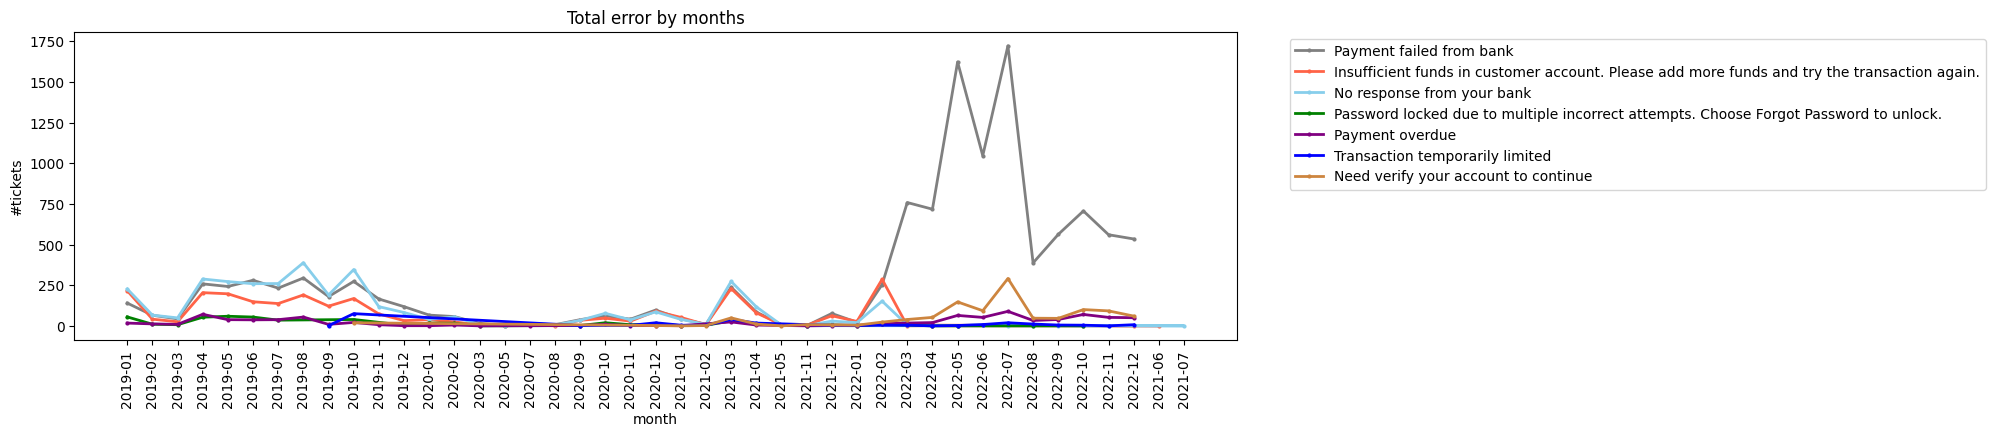

In [ ]:
error_color_pairs = [
    ('Payment failed from bank', 'gray'),
    ('Insufficient funds in customer account. Please add more funds and try the transaction again.', 'tomato'),
    ('No response from your bank', 'skyblue'),
    ('Password locked due to multiple incorrect attempts. Choose Forgot Password to unlock.', 'green'),
    ('Payment overdue', 'purple'),
    ('Transaction temporarily limited', 'blue'),
    ('Need verify your account to continue', 'peru')
]

plt.figure(figsize=(15, 4))
for error, color in error_color_pairs:
    df_err_line = df_error_des[df_error_des['description'] == error]
    plt.plot(df_err_line['year_month'], df_err_line['total'],
             label=error, marker='o', color=color, linewidth=2, markersize=2)

plt.title('Total error by months')
plt.xlabel('month')
plt.ylabel('#tickets')
plt.legend(loc='upper right', bbox_to_anchor=(1.65, 1))
plt.xticks(rotation=90)
plt.show()

###SR=0%.Why and How ?

In [ ]:
list_sr_0=list((df_customer_value[df_customer_value['success_rate']<0.1]['customer_id']).unique())

In [ ]:
def calc_n_promotions(x):
  return(x=='promotion').sum()
df_sr_0_metric=(
    df_j_all[df_j_all['customer_id'].isin(list_sr_0)]
    .groupby('customer_id')
    .agg(n_order=('ticket_id','count')
    ,n_money=('original_price','sum')
    ,n_discount=('discount_value','sum')
    ,n_promotion=('type',calc_n_promotions))
    .reset_index()

)

In [ ]:
df_sr_0_metric['promotion_rate']=df_sr_0_metric['n_promotion']/df_sr_0_metric['n_order']
df_sr_0_metric['discount_rate']=df_sr_0_metric['n_discount']/df_sr_0_metric['n_money']

array([[<Axes: title={'center': 'n_order'}>,
        <Axes: title={'center': 'n_money'}>],
       [<Axes: title={'center': 'n_discount'}>,
        <Axes: title={'center': 'n_promotion'}>],
       [<Axes: title={'center': 'promotion_rate'}>,
        <Axes: title={'center': 'discount_rate'}>]], dtype=object)

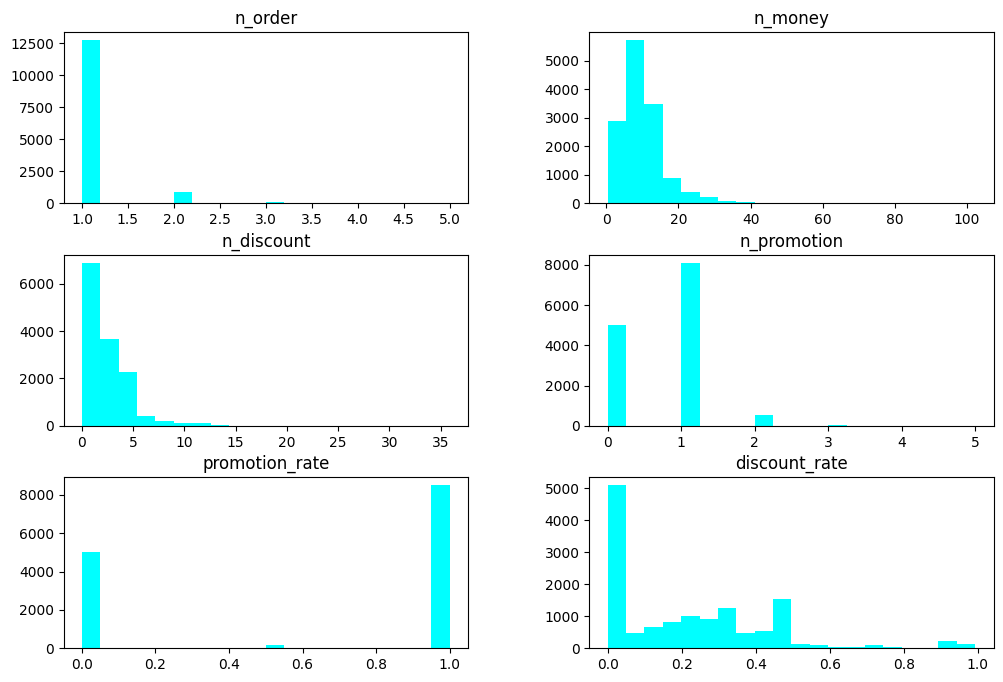

In [ ]:
df_sr_0_metric.iloc[:,1:].hist(figsize=(12,8),grid=False , color='cyan',bins=20)

In [ ]:
df_error_0=(
    df_j_all[df_j_all['status_id']!=1][df_j_all['customer_id'].isin(list_sr_0)]
    .groupby(['year_month','description'])
    .agg(total=('ticket_id','count'))
    .sort_values('year_month',ascending=True)
    .reset_index()
)

/tmp/ipython-input-3929738921.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_j_all[df_j_all['status_id']!=1][df_j_all['customer_id'].isin(list_sr_0)]


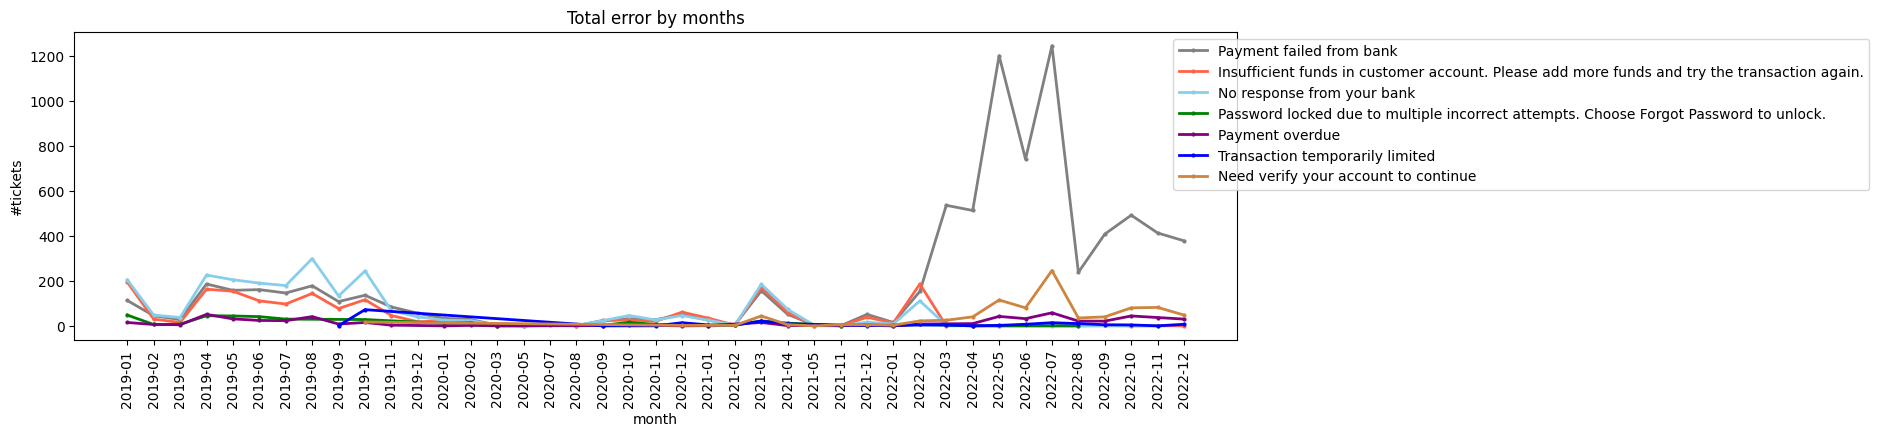

In [ ]:
error_color_pairs = [
    ('Payment failed from bank', 'gray'),
    ('Insufficient funds in customer account. Please add more funds and try the transaction again.', 'tomato'),
    ('No response from your bank', 'skyblue'),
    ('Password locked due to multiple incorrect attempts. Choose Forgot Password to unlock.', 'green'),
    ('Payment overdue', 'purple'),
    ('Transaction temporarily limited', 'blue'),
    ('Need verify your account to continue', 'peru')
]

plt.figure(figsize=(15, 4))
for error, color in error_color_pairs:
    df_err_line = df_error_0[df_error_0['description'] == error]
    plt.plot(df_err_line['year_month'], df_err_line['total'],
             label=error, marker='o', color=color, linewidth=2, markersize=2)

plt.title('Total error by months')
plt.xlabel('month')
plt.ylabel('#tickets')
plt.legend(loc='upper right', bbox_to_anchor=(1.55, 1))
plt.xticks(rotation=90)
plt.show()

>**Note**

>- Nhóm lỗi này cũng gần như là nhóm bị lỗi của toàn bộ KH
>- Lý do họ stop
>>- Lỗi bên ngân hàng , họ không chủ động được nữa
>>- Lỗi xác thực tài khoản-->Nghi ngờ gian lận hoặc không đủ điều kiện upgrade tài khoản